# Olist E-Commerce Analytics Project

## Business Objective
Analyze ecommerce operations, customer behavior, payment activity, delivery efficiency, and customer satisfaction using the Brazilian Olist ecommerce dataset.

## Project Goals
- Understand the ecommerce business workflow.
- Map relationships between operational tables.
- Audit data quality before analysis.
- Investigate missing values using business context.
- Prepare the dataset for future SQL, KPI, and machine learning analysis.

## Analytical Workflow
1. Understand the business system.
2. Map table relationships.
3. Audit data quality: nulls, duplicates, and data types.
4. Investigate issues using evidence from related columns.
5. Create purpose-specific datasets based on business questions.


# 1. Import Libraries


In [ ]:
# Create a visualization to make the pattern easier to interpret.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


# 2. Load Core Datasets

The first tables loaded are the core operational tables:

- **orders**: order lifecycle and delivery timestamps
- **customers**: customer identity and location
- **payments**: payment method and payment value
- **reviews**: customer satisfaction feedback

Using a relative `data` path makes the notebook easier to move between computers and GitHub.


In [ ]:
# Load dataset from CSV file into a pandas DataFrame.
DATA_DIR = Path("../data")

orders_df = pd.read_csv(DATA_DIR / "olist_orders_dataset.csv")
customers_df = pd.read_csv(DATA_DIR / "olist_customers_dataset.csv")
payments_df = pd.read_csv(DATA_DIR / "olist_order_payments_dataset.csv")
reviews_df = pd.read_csv(DATA_DIR / "olist_order_reviews_dataset.csv")
products_df=pd.read_csv(DATA_DIR/"olist_products_dataset.csv")
sellers_df=pd.read_csv(DATA_DIR/"olist_sellers_dataset.csv")
product_category_name_translation_df=pd.read_csv(DATA_DIR/"product_category_name_translation.csv")
order_payments_df=pd.read_csv(DATA_DIR/"olist_order_payments_dataset.csv")


# 3. Initial Table Preview

Before analysis, inspect the first few rows of each dataset to understand what each table represents.


In [ ]:
# Preview the first rows to understand the table structure and sample values.
orders_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
# Preview the first rows to understand the table structure and sample values.
customers_df.head()


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [ ]:
# Preview the first rows to understand the table structure and sample values.
payments_df.head()


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [ ]:
# Preview the first rows to understand the table structure and sample values.
reviews_df.head()


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


# 4. Schema Inspection and Relationship Mapping

The goal here is to identify key columns that connect tables together.

Expected relationships:

- `orders_df.customer_id` connects to `customers_df.customer_id`
- `orders_df.order_id` connects to `payments_df.order_id`
- `orders_df.order_id` connects to `reviews_df.order_id`

This reconstructs the business workflow:

**customer → order → payment approval → delivery → review**


In [ ]:
# Review column names to understand available fields and possible join keys.
print("Orders columns:")
print(orders_df.columns)

print("Customers columns:")
print(customers_df.columns)

print("Payments columns:")
print(payments_df.columns)

print("Reviews columns:")
print(reviews_df.columns)


Orders columns:
Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')
Customers columns:
Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')
Payments columns:
Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='str')
Reviews columns:
Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='str')


# 5. Store DataFrames in a Dictionary

This allows reusable audit functions to run across multiple tables instead of checking each dataframe manually.


In [ ]:
# Run this analysis step and display the result for interpretation.
dataframes = {
    "orders": orders_df,
    "customers": customers_df,
    "payments": payments_df,
    "reviews": reviews_df
}


# 6. Data Quality Audit — Null Values

Null values should not be removed blindly. Some nulls may represent valid business states, such as orders that were canceled, still processing, or not yet delivered.

This function calculates both the count and percentage of null values for each table.


In [ ]:
# Check missing values to identify potential data-quality issues.
def check_null_percentage(dataframes):
    """
    Check null counts and null percentages for each dataframe.
    Only columns with at least one null value are displayed.
    """
    for name, df in dataframes.items():
        print(f"{name}")
        print("-" * 50)

        null_counts = df.isnull().sum()
        null_percentage = (null_counts / len(df)) * 100

        result = pd.DataFrame({
            "Null_Count": null_counts,
            "Null_Percentage": null_percentage
        })

        print(result[result["Null_Count"] > 0])


In [ ]:
# Run this analysis step and display the result for interpretation.
check_null_percentage(dataframes)


orders
--------------------------------------------------
                               Null_Count  Null_Percentage
order_approved_at                     160         0.160899
order_delivered_carrier_date         1783         1.793023
order_delivered_customer_date        2965         2.981668
customers
--------------------------------------------------
Empty DataFrame
Columns: [Null_Count, Null_Percentage]
Index: []
payments
--------------------------------------------------
Empty DataFrame
Columns: [Null_Count, Null_Percentage]
Index: []
reviews
--------------------------------------------------
                        Null_Count  Null_Percentage
review_comment_title         87656        88.341530
review_comment_message       58247        58.702532


## Null Value Interpretation

Initial observations:

- The **customers** and **payments** tables have no missing values in the inspected columns.
- The **orders** table has missing timestamps related to approval, carrier delivery, and customer delivery.
- The **reviews** table has many missing comment titles and messages, likely because written comments are optional while review scores are still present.

Important principle:

> High null percentage does not automatically mean bad data. Business context determines whether a null is harmful, normal, or meaningful.


# 7. Investigate Missing Delivery Dates Using Order Status

Business question:

> Why are some `order_delivered_customer_date` values missing?

Because we do not have direct contact with the business team, we investigate using related columns. The most useful related column is `order_status`.


In [ ]:
# Count records by category to understand frequency distribution.
orders_df[
    orders_df["order_delivered_customer_date"].isnull()
]["order_status"].value_counts()


order_status
shipped        1107
canceled        619
unavailable     609
invoiced        314
processing      301
delivered         8
created           5
approved          2
Name: count, dtype: int64

## Interpretation

Missing delivery dates are mostly linked to statuses such as:

- `shipped`: likely still in transit
- `canceled`: order was canceled before delivery
- `unavailable`: fulfillment issue
- `processing` / `invoiced`: order workflow not completed yet

This suggests most missing delivery dates are valid operational states, not simple data errors.


# 8. Inspect Order Status Values

Order status values define the lifecycle stages of an order. These are important business process states.


In [ ]:
# Run this analysis step and display the result for interpretation.
orders_df["order_status"].unique()


<StringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str

In [ ]:
# Count records by category to understand frequency distribution.
orders_df["order_status"].value_counts()


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

# 9. Investigate Suspicious Case: Delivered Orders With Missing Delivery Date

A delivered order should normally have a customer delivery timestamp. These rows may indicate data inconsistencies.


In [ ]:
# Run this analysis step and display the result for interpretation.
delivered_missing = orders_df[
    (orders_df["order_status"] == "delivered") &
    (orders_df["order_delivered_customer_date"].isnull())
]

len(delivered_missing)


8

In [ ]:
# Preview the first rows to understand the table structure and sample values.
delivered_missing.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
43834,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
79263,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaN,2018-07-30 00:00:00
82868,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaN,2018-07-24 00:00:00


## Interpretation

Only a very small number of delivered orders are missing the customer delivery date. This suggests the overall delivery timestamp quality is strong, but these records should be treated carefully in delivery-time analysis.

Important principle:

> Cleaning depends on the business question. For delivery-duration analysis, it is reasonable to focus only on delivered orders with valid delivery timestamps.


# 10. Data Quality Audit — Duplicate Rows

Duplicates should also be checked before joining or aggregating data.


In [ ]:
# Check duplicate rows to identify possible data-quality issues.
def check_duplicates(dataframes):
    """
    Check exact duplicate rows for each dataframe.
    """
    for name, df in dataframes.items():
        print(f"{name}")
        print("-" * 40)
        print("Duplicate Rows:", df.duplicated().sum())


In [ ]:
# Run this analysis step and display the result for interpretation.
check_duplicates(dataframes)


orders
----------------------------------------
Duplicate Rows: 0
customers
----------------------------------------
Duplicate Rows: 0
payments
----------------------------------------
Duplicate Rows: 0
reviews
----------------------------------------
Duplicate Rows: 0


# 11. Data Type Validation

Timestamp columns were imported as strings from CSV. They must be converted to datetime before calculating durations or time-based KPIs.


In [ ]:
# Review data types to identify columns that need conversion before analysis.
orders_df.dtypes


order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

# 12. Convert Timestamp Columns to Datetime

Datetime conversion enables:

- approval delay analysis
- delivery duration analysis
- late delivery analysis
- monthly trend analysis
- forecasting and time-series workflows


In [ ]:
# Convert timestamp columns to datetime so time-based KPIs can be calculated correctly.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])


In [ ]:
# Review data types to identify columns that need conversion before analysis.
orders_df.dtypes


order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [ ]:
# Convert timestamp columns to datetime so time-based KPIs can be calculated correctly.
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    
    orders_df[col] = pd.to_datetime(
        orders_df[col]
    )

In [ ]:
# Review data types to identify columns that need conversion before analysis.
orders_df.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

# 13. Key Learning Summary

This notebook is currently focused on **data understanding and validation**, not final business KPIs yet.

Main learning points:

- Business-system understanding comes before analysis.
- Null values require context before cleaning.
- Some nulls represent valid operational states.
- Reusable audit functions improve scalability.
- Data type validation is required before time-based analysis.
- Analysis datasets should be created based on specific business questions.

Next steps:

1. Validate table cardinality and one-to-many relationships.
2. Load `order_items`, `products`, and `sellers` tables.
3. Join core ecommerce tables.
4. Build first operational KPIs such as delivery duration, late delivery rate, and revenue by state.


# Order Items Exploration

## Objective
Understand order granularity and investigate one-to-many relationships between orders and purchased items.

In [ ]:
# Load dataset from CSV file into a pandas DataFrame.
order_items_df =pd.read_csv(DATA_DIR /'olist_order_items_dataset.csv')

In [ ]:
# Review column names to understand available fields and possible join keys.
order_items_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='str')

In [ ]:
# Preview the first rows to understand the table structure and sample values.
order_items_df.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
# Run this analysis step and display the result for interpretation.
order_items_df.shape

(112650, 7)

In [ ]:
# Confirm Multiple Items Per Order
#this table is item-level granularity.
#“How many rows/items belong to each order?”
order_items_df["order_id"].value_counts()

order_id
8272b63d03f5f79c56e9e4120aec44ef    21
1b15974a0141d54e36626dca3fdc731a    20
ab14fdcfbe524636d65ee38360e22ce8    20
428a2f660dc84138d969ccd69a0ab6d5    15
9ef13efd6949e4573a18964dd1bbe7f5    15
                                    ..
fffc94f6ce00a00581880bf54a75a037     1
fffcd46ef2263f404302a634eb57f7eb     1
fffce4705a9662cd70adb13d4a31832d     1
fffe18544ffabc95dfada21779c9644f     1
fffe41c64501cc87c801fd61db3f6244     1
Name: count, Length: 98666, dtype: int64

In [ ]:
# Merge related tables to combine business metrics needed for this analysis.
orders_items_joined=pd.merge(orders_df,order_items_df,on='order_id',how='inner')

In [ ]:
# Run this analysis step and display the result for interpretation.
orders_items_joined

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112645,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
112646,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
112647,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
112648,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [ ]:
# Run this analysis step and display the result for interpretation.
print("Orders Shape:")
print(orders_df.shape)

print("\nJoined Shape:")
print(orders_items_joined.shape)

Orders Shape:
(99441, 8)

Joined Shape:
(112650, 14)


In [ ]:
#investage revenue columns
order_items_df[
    ["order_id", "price", "freight_value"]
].head()

,order_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14


In [ ]:
# Review data types to identify columns that need conversion before analysis.
orders_items_joined.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
order_item_id                             int64
product_id                                  str
seller_id                                   str
shipping_limit_date                         str
price                                   float64
freight_value                           float64
dtype: object

In [ ]:
#safe customer revenue calculation.
revenue_per_order= order_items_df.groupby('order_id')['price'].sum().reset_index()
revenue_per_order.head()

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [ ]:
#join with orders
orders_revenue=pd.merge(revenue_per_order,orders_df,on='order_id',how='inner')

In [ ]:
# Run this analysis step and display the result for interpretation.
orders_revenue

,order_id,price,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,239.90,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,199.00,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,12.99,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17
...,...,...,...,...,...,...,...,...,...
98661,fffc94f6ce00a00581880bf54a75a037,299.99,b51593916b4b8e0d6f66f2ae24f2673d,delivered,2018-04-23 13:57:06,2018-04-25 04:11:01,2018-04-25 12:09:00,2018-05-10 22:56:40,2018-05-18
98662,fffcd46ef2263f404302a634eb57f7eb,350.00,84c5d4fbaf120aae381fad077416eaa0,delivered,2018-07-14 10:26:46,2018-07-17 04:31:48,2018-07-17 08:05:00,2018-07-23 20:31:55,2018-08-01
98663,fffce4705a9662cd70adb13d4a31832d,99.90,29309aa813182aaddc9b259e31b870e6,delivered,2017-10-23 17:07:56,2017-10-24 17:14:25,2017-10-26 15:13:14,2017-10-28 12:22:22,2017-11-10
98664,fffe18544ffabc95dfada21779c9644f,55.99,b5e6afd5a41800fdf401e0272ca74655,delivered,2017-08-14 23:02:59,2017-08-15 00:04:32,2017-08-15 19:02:53,2017-08-16 21:59:40,2017-08-25


In [ ]:
# Run this analysis step and display the result for interpretation.
orders_revenue.shape

(98666, 9)

In [ ]:
# Run this analysis step and display the result for interpretation.
orders_df.shape

(99441, 8)

In [ ]:
#Customer Revenue
customer_revenue = (
    orders_revenue
    .groupby("customer_id")["price"]
    .sum()
    .reset_index()
)

customer_revenue.head()

,customer_id,price
0,00012a2ce6f8dcda20d059ce98491703,89.80
1,000161a058600d5901f007fab4c27140,54.90
2,0001fd6190edaaf884bcaf3d49edf079,179.99
3,0002414f95344307404f0ace7a26f1d5,149.90
4,000379cdec625522490c315e70c7a9fb,93.00


In [ ]:
# Run this analysis step and display the result for interpretation.
customer_revenue.shape

(98666, 2)

In [ ]:
#datetime analysis.
#create delivery durantion
orders_df['delivery_days']=(orders_df['order_delivered_customer_date']
- orders_df['order_purchase_timestamp']).dt.days

In [ ]:
#check result
orders_df[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "delivery_days"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2.0


In [ ]:
#investage delivery preformance 
#Step 1 — Create Late Delivery Feature
orders_df["late_delivery"] = (
    orders_df["order_delivered_customer_date"]
    >
    orders_df["order_estimated_delivery_date"]
)

In [ ]:
# Preview the first rows to understand the table structure and sample values.
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False


In [ ]:
#count late delivery 
orders_df["late_delivery"].value_counts()

late_delivery
False    91614
True      7827
Name: count, dtype: int64

In [ ]:
# Create a late-delivery flag by comparing actual delivery date with estimated delivery date.
orders_df["late_delivery"].value_counts(normalize=True) * 100

late_delivery
False    92.129001
True      7.870999
Name: proportion, dtype: float64

In [ ]:
# Check missing values to identify potential data-quality issues.
orders_df["late_delivery"].isnull().sum()

np.int64(0)

In [ ]:
#relationship between operational performance and customer satisfaction.
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [ ]:
#to confirm granularity 
reviews_df['order_id'].nunique()

98673

In [ ]:
#this to confirm granulirty is not same level some orders are repated 
reviews_df.shape

(99224, 7)

In [ ]:
#investage the multiple orders 
reviews_df['order_id'].value_counts()

order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
                                   ..
2a8c23fee101d4d5662fa670396eb8da    1
22ec9f0669f784db00fa86d035cf8602    1
55d4004744368f5571d1f590031933e4    1
7725825d039fc1f0ceb7635e3f7d9206    1
90531360ecb1eec2a1fbb265a0db0508    1
Name: count, Length: 98673, dtype: int64

In [ ]:
# Sort results to rank records by the selected metric.
reviews_df[reviews_df['order_id'].duplicated(keep=False)].sort_values('order_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
...,...,...,...,...,...,...,...
27465,5e78482ee783451be6026e5cf0c72de1,ff763b73e473d03c321bcd5a053316e8,3,NaN,Não sei que haverá acontecido os demais chegaram,2017-11-18 00:00:00,2017-11-18 09:02:48
41355,39de8ad3a1a494fc68cc2d5382f052f4,ff850ba359507b996e8b2fbb26df8d03,5,NaN,Envio rapido... Produto 100%,2017-08-16 00:00:00,2017-08-17 11:56:55
18783,80f25f32c00540d49d57796fb6658535,ff850ba359507b996e8b2fbb26df8d03,5,NaN,"Envio rapido, produto conforme descrito no anu...",2017-08-22 00:00:00,2017-08-25 11:40:22
92230,870d856a4873d3a67252b0c51d79b950,ffaabba06c9d293a3c614e0515ddbabc,3,NaN,NaN,2017-12-20 00:00:00,2017-12-20 18:50:16


In [ ]:
#lets check how many orders are repeated 1098 is duplicated reviews 
#Okay, now SHOW ME every row belonging to those repeated orders.”
reviews_df[
    reviews_df["order_id"].duplicated(keep=False)
].shape

(1098, 7)

In [ ]:
# Run this analysis step and display the result for interpretation.
duplicate_reviews = reviews_df[
    reviews_df["order_id"].duplicated(keep=False)
]

duplicate_reviews.head(10)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
30,540e7bbb2d06cfb7f85f3a88ba7ac97f,cf73e2cb1f4a9480ed70c154da3d954a,5,NaN,NaN,2018-01-18 00:00:00,2018-01-18 19:12:30
344,a0a641414ff718ca079b3967ef5c2495,169d7e0fd71d624d306f132acd791cbe,5,NaN,NaN,2018-03-04 00:00:00,2018-03-06 20:12:53
498,505a882ba08a689682a4afc6eb4e5965,1c308eca3f339414a92e518e2a2e5ee9,2,NaN,NaN,2017-12-28 00:00:00,2017-12-31 20:25:02
764,c5976a5a98e854fb23d7e03c6754ae60,2002ea16e75277eaa0b5d78632048540,5,NaN,NaN,2017-08-08 00:00:00,2017-08-10 11:11:29
778,62c7722239b976d943ec0d430cfe890e,1d297b4800ed1a3c5b0944d84c01ee99,3,NaN,NaN,2017-10-22 00:00:00,2017-10-31 15:33:32
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
1023,948a6406a9e50a798f9e3c5b3dfced86,b6e5aa946acc4e29e7069510f28a0bce,5,NaN,NaN,2017-01-27 00:00:00,2017-01-27 23:51:32
1028,afd9b3d196f0acd81d79d8ccd79c2430,5040757d4e06a4be96d3827b860b4e7c,5,NaN,NaN,2017-10-31 00:00:00,2017-11-04 21:12:29
1030,8f5f4febd3fa6a40b41756f6616bf0e7,80446aee36e09ebf4cb79585f6c9ce61,5,NaN,NaN,2017-09-23 00:00:00,2017-09-24 02:00:04
1055,9c0ff4d25d28bd004057ce16540abc3d,45390ff93f092f0de1524d486a172c33,1,NaN,A mercadoria não foi entregue ainda..,2018-03-21 00:00:00,2018-03-26 22:01:59


In [ ]:
#now we investage wether the reviews are identical duplicates or gennuinely different review 
# srecord
duplicate_reviews.sort_values('order_id').head(20)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
25612,89a02c45c340aeeb1354a24e7d4b2c1e,0035246a40f520710769010f752e7507,5,NaN,NaN,2017-08-29 00:00:00,2017-08-30 01:59:12
22423,2a74b0559eb58fc1ff842ecc999594cb,0035246a40f520710769010f752e7507,5,NaN,Estou acostumada a comprar produtos pelo barat...,2017-08-25 00:00:00,2017-08-29 21:45:57
22779,ab30810c29da5da8045216f0f62652a2,013056cfe49763c6f66bda03396c5ee3,5,NaN,NaN,2018-02-22 00:00:00,2018-02-23 12:12:30
68633,73413b847f63e02bc752b364f6d05ee9,013056cfe49763c6f66bda03396c5ee3,4,NaN,NaN,2018-03-04 00:00:00,2018-03-05 17:02:00
854,830636803620cdf8b6ffaf1b2f6e92b2,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:06
83224,d8e8c42271c8fb67b9dad95d98c8ff80,0176a6846bcb3b0d3aa3116a9a768597,5,NaN,NaN,2017-12-30 00:00:00,2018-01-02 10:54:47
17582,017f0e1ea6386de662cbeba299c59ad1,02355020fd0a40a0d56df9f6ff060413,1,NaN,ja reclamei varias vezes e ate hoje não sei on...,2018-03-29 00:00:00,2018-03-30 03:16:19
89888,0c8e7347f1cdd2aede37371543e3d163,02355020fd0a40a0d56df9f6ff060413,3,NaN,UM DOS PRODUTOS (ENTREGA02) COMPRADOS NESTE PE...,2018-03-21 00:00:00,2018-03-22 01:32:08
55137,61fe4e7d1ae801bbe169eb67b86c6eda,029863af4b968de1e5d6a82782e662f5,4,NaN,NaN,2017-07-19 00:00:00,2017-07-20 12:06:11
37911,04d945e95c788a3aa1ffbee42105637b,029863af4b968de1e5d6a82782e662f5,5,NaN,NaN,2017-07-14 00:00:00,2017-07-17 13:58:06


In [ ]:
#how may reviews per duplicated order repeated reivew behavior exist 
#how many review rows each repeated order has.
duplicate_reviews['order_id'].value_counts()

order_id
c88b1d1b157a9999ce368f218a407141    3
df56136b8031ecd28e200bb18e6ddb2e    3
03c939fd7fd3b38f8485a0f95798f1f6    3
8e17072ec97ce29f0e1f111e598b0c85    3
cf73e2cb1f4a9480ed70c154da3d954a    2
                                   ..
e00ed9d20c3479f9f0e9727ca9d60946    2
5c2049caca936695cfa43805ebe7d8e3    2
6066fbcebeaf378770ad9fbe8e30d1f0    2
2739713764165279791b394484947e2d    2
157de1652c032429a625d034be79eeeb    2
Name: count, Length: 547, dtype: int64

In [ ]:
#check duplicated order have different scores
#Do repeated review rows contain the SAME score or DIFFERENT scores?”
#1	the order has ONLY ONE unique score repeated
#2	the order has TWO DIFFERENT scores
duplicate_reviews.groupby(
    "order_id"
)["review_score"].nunique().value_counts()

review_score
1    345
2    202
Name: count, dtype: int64

In [ ]:
#Do late deliveries reduce review scores?
review_per_order=reviews_df.groupby('order_id')['review_score'].mean().reset_index()

In [ ]:
#JOIN WITH ORDER
orders_reviews = pd.merge(
    orders_df,
    review_per_order,
    on="order_id",
    how="inner"
)

orders_reviews.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,late_delivery,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,False,4.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,False,4.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,False,5.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,False,5.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,False,5.0


In [ ]:
#Do customers give lower scores when deliveries are late?”
#Late deliveries are strongly associated with: worse customer satisfaction worse customer satisfaction.
orders_reviews.groupby(
    "late_delivery"
)["review_score"].mean()

late_delivery
False    4.214778
True     2.566562
Name: review_score, dtype: float64

# 14. Operational Insight — Delivery Delays and Customer Satisfaction

Business finding:

Late deliveries are strongly associated with lower customer review scores.

Average review scores:
- On-time deliveries: ~4.21
- Late deliveries: ~2.57

This suggests delivery performance has a major impact on customer satisfaction and overall customer experience.

# 15. Delay Severity Analysis

Late delivery is not only a binary problem.

This section investigates:
- how early or late deliveries are
- delivery delay distribution
- whether severe delays affect customer sentiment differently

A new feature called `delay_days` was engineered:

- Negative values = delivered earlier than estimated
- Positive values = delivered later than estimated

In [ ]:
#Create Delay Magnitude Feature

orders_reviews["delay_days"] = (
    orders_reviews["order_delivered_customer_date"]
    -
    orders_reviews["order_estimated_delivery_date"]
).dt.days

In [ ]:
# Generate summary statistics to understand distribution, skewness, and outliers.
orders_reviews["delay_days"].describe()

count    95830.000000
mean       -11.914067
std         10.113511
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delay_days, dtype: float64

In [ ]:
# Aggregate review metrics to compare customer satisfaction across groups.
orders_reviews.groupby(
    "delay_days"
)["review_score"].mean().head(20)

delay_days
-147.0    5.000000
-140.0    5.000000
-135.0    3.000000
-124.0    5.000000
-109.0    5.000000
-84.0     5.000000
-83.0     5.000000
-78.0     5.000000
-77.0     5.000000
-76.0     5.000000
-75.0     4.500000
-73.0     5.000000
-71.0     4.500000
-69.0     3.666667
-68.0     5.000000
-67.0     5.000000
-66.0     5.000000
-65.0     5.000000
-64.0     5.000000
-63.0     5.000000
Name: review_score, dtype: float64

# 16. Delivery Performance Summary

Key operational observations:

- Most deliveries arrive earlier than the estimated delivery date.
- Median delay is approximately -12 days, meaning half of deliveries arrive at least 12 days early.
- The business appears to use conservative delivery estimates.
- A small number of extreme late deliveries still exist and likely contribute heavily to poor customer reviews.

This demonstrates how operational metrics can directly influence customer satisfaction outcomes.

In [ ]:
#customer segmentation behavior
#Do some customers spend significantly more than others?
#create customer revenue table 
customer_revenue = (
    orders_revenue
    .groupby("customer_id")["price"]
    .sum()
    .reset_index()
)

customer_revenue.head()

,customer_id,price
0,00012a2ce6f8dcda20d059ce98491703,89.80
1,000161a058600d5901f007fab4c27140,54.90
2,0001fd6190edaaf884bcaf3d49edf079,179.99
3,0002414f95344307404f0ace7a26f1d5,149.90
4,000379cdec625522490c315e70c7a9fb,93.00


In [ ]:
#customer spending bevahoir 
customer_revenue['price'].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: price, dtype: float64

# 17. Customer Revenue Distribution Insight

Customer spending behavior appears heavily right-skewed.

Key observations:
- Median customer spend is much lower than the mean.
- A small number of customers spend extremely large amounts.
- Revenue is likely concentrated among a relatively small group of high-value customers.

This type of distribution is common in ecommerce businesses and is important for:
- VIP customer retention
- loyalty programs
- personalized marketing
- customer segmentation strategies

Visualization


In [ ]:
# Create a visualization to make the pattern easier to interpret.
import matplotlib.pyplot as plt 
import seaborn as sns

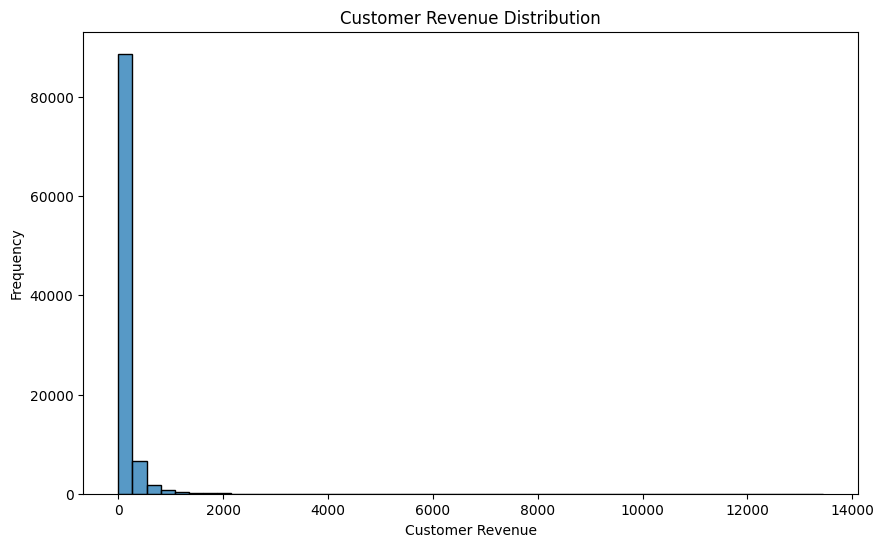

In [ ]:
#polt customer revenue distribution 
plt.figure(figsize=(10,6))
sns.histplot(customer_revenue['price'],
             bins=50)
plt.title("Customer Revenue Distribution")
plt.xlabel("Customer Revenue")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#Remove Extreme Outliers For Visualization We are NOT deleting data permanently beacuse 13,440 compress the cahrt scale.
filtered_revenue = customer_revenue[
    customer_revenue["price"] < 1000
]

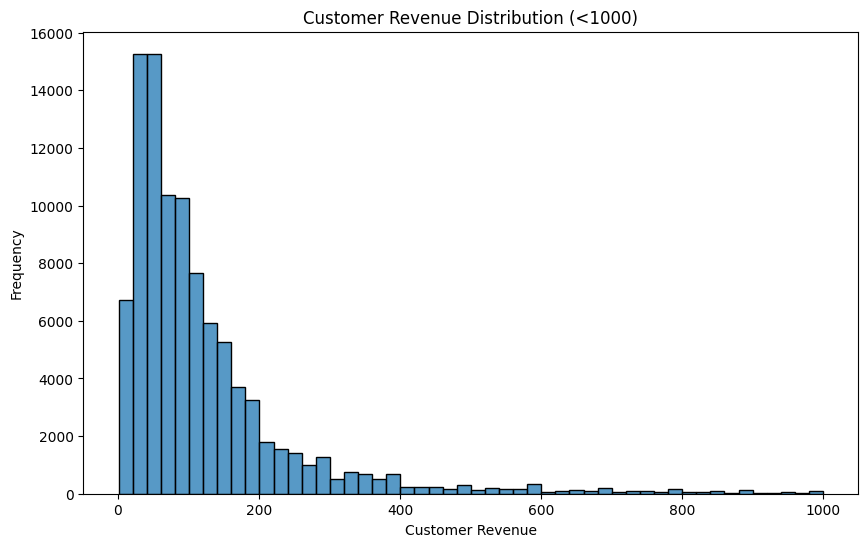

In [ ]:
#most customers spend relatively small amounts. huge customer concentration spending more in range of 50 150
plt.figure(figsize=(10, 6))

sns.histplot(
    filtered_revenue["price"],
    bins=50
)

plt.title("Customer Revenue Distribution (<1000)")
plt.xlabel("Customer Revenue")
plt.ylabel("Frequency")

plt.show()

In [ ]:
#“Who are the highest-value customers?” distribution analysis customer segmentaion
#quct it split customers roughly into  equal rows
customer_revenue["customer_segment"] = pd.qcut(
    customer_revenue["price"],
    q=4,
    labels=[
        "Low Value",
        "Mid Value",
        "High Value",
        "VIP"
    ]
)

In [ ]:
#inspect segement counts
customer_revenue["customer_segment"].value_counts()

customer_segment
Low Value     24756
High Value    24692
Mid Value     24653
VIP           24565
Name: count, dtype: int64

In [ ]:
#inspect revenue ranges
customer_revenue.groupby(
    "customer_segment"
)["price"].describe()

,count,mean,std,min,25%,50%,75%,max
customer_segment,,,,,,,,
Low Value,24756.0,28.595505,10.005643,0.85,19.99,29.00,37.00,45.9
Mid Value,24653.0,63.962895,11.584644,45.91,53.99,60.00,73.76,86.9
High Value,24692.0,115.106669,18.663987,86.96,99.70,113.57,129.90,149.9
VIP,24565.0,344.581407,341.862731,149.91,179.99,231.20,358.92,13440.0


### Customer Revenue Segmentation Summary

Customers were segmented into four equal-sized groups using `pd.qcut()` based on total customer revenue.

The segmentation created the following customer tiers:
- Low Value
- Mid Value
- High Value
- VIP

Each segment contains approximately the same number of customers, allowing balanced comparison between spending behaviors.

---

### Low Value Customers

- Average spending is approximately 28
- Spending variability is low (`std ≈ 10`)
- Maximum spending is around 45

This segment represents low-spending or casual customers with relatively consistent purchasing behavior.

---

### Mid Value Customers

- Average spending is approximately 64
- Spending variability remains moderate (`std ≈ 11`)
- Spending range is more stable compared to higher segments

This group likely represents the normal or core customer base.

---

### High Value Customers

- Average spending is approximately 115
- Spending variability increases (`std ≈ 18`)
- Customers spend significantly more than the typical customer

These customers may represent more engaged or repeat buyers and are strong candidates for retention and loyalty strategies.

---

### VIP Customers

- Average spending is approximately 344
- Standard deviation is also very high (`std ≈ 341`)
- Maximum spending reaches 13,440

Because the standard deviation is almost as large as the mean, this indicates extremely high variability within the VIP segment.

This suggests the VIP group is not homogeneous:
- some VIP customers spend moderately high amounts
- while a smaller subset spends extremely large amounts

This may indicate the existence of ultra high-value customers inside the VIP segment.

---

### Overall Business Insight

Customer revenue distribution is strongly right-skewed:
- most customers spend relatively small amounts
- while a smaller group contributes disproportionately large revenue

This type of segmentation is highly valuable for:
- customer retention
- loyalty programs
- personalized marketing
- revenue concentration analysis
- high-value customer targeting

#customer satisfaction and customer segementaion

In [ ]:
#does high value customer leave different reivew score 
#unhappy VIPs are expensive to lose
#high-value customers may expect better service
#retention strategy depends on this

In [ ]:
#Customer level reivew averge 
customer_review= (orders_reviews.groupby('customer_id')['review_score'].mean().reset_index())

In [ ]:
#Do spending patterns relate to customer satisfaction
customer_analysis=pd.merge(customer_revenue,customer_review, 
                           on='customer_id',how='inner')
customer_analysis.head(10)

,customer_id,price,customer_segment,review_score
0,00012a2ce6f8dcda20d059ce98491703,89.80,High Value,1.0
1,000161a058600d5901f007fab4c27140,54.90,Mid Value,4.0
2,0001fd6190edaaf884bcaf3d49edf079,179.99,VIP,5.0
3,0002414f95344307404f0ace7a26f1d5,149.90,High Value,5.0
4,000379cdec625522490c315e70c7a9fb,93.00,High Value,4.0
5,0004164d20a9e969af783496f3408652,59.99,Mid Value,1.0
6,000419c5494106c306a97b5635748086,34.30,Low Value,1.0
7,00046a560d407e99b969756e0b10f282,120.90,High Value,5.0
8,00050bf6e01e69d5c0fd612f1bcfb69c,69.99,Mid Value,5.0
9,000598caf2ef4117407665ac33275130,1107.00,VIP,5.0


In [ ]:
#meadin is 5 this mean half of customer give prefect rating  also still customer give 1,2 3 which 
#mean customer statisfaction is not consistence std is far from the mean 
customer_analysis.describe()

,price,review_score
count,97917.000000,97917.000000
mean,137.534289,4.105055
std,209.482616,1.330316
min,0.850000,1.000000
25%,45.900000,4.000000
50%,86.900000,5.000000
75%,149.900000,5.000000
max,13440.000000,5.000000


In [ ]:
#As customer spending increases: satisfaction slightly decreases there is a consistent downward trend.
#Higher-value customer segments exhibit slightly lower average review scores compared to lower-value segments.
customer_analysis.groupby('customer_segment')['review_score'].mean()

customer_segment
Low Value     4.171316
Mid Value     4.130625
High Value    4.112416
VIP           4.004992
Name: review_score, dtype: float64

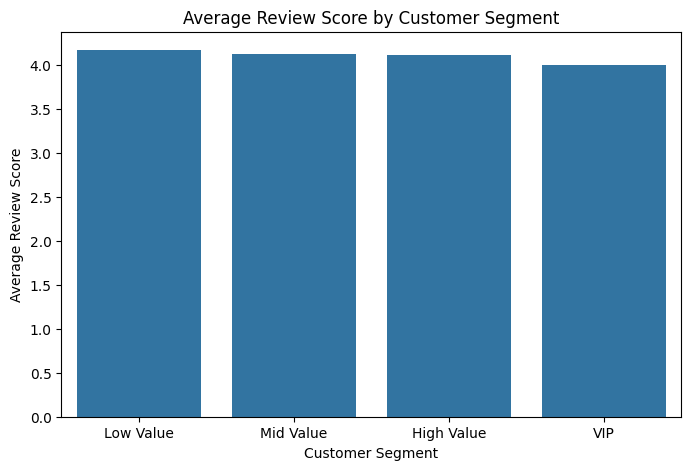

In [ ]:
# Aggregate review metrics to compare customer satisfaction across groups.
segment_reviews = (
    customer_analysis
    .groupby("customer_segment")["review_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=segment_reviews,
    x="customer_segment",
    y="review_score"
)

plt.title("Average Review Score by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Average Review Score")

plt.show()

In [ ]:
# Preview the first rows to understand the table structure and sample values.
customer_analysis.head()

,customer_id,price,customer_segment,review_score
0,00012a2ce6f8dcda20d059ce98491703,89.80,High Value,1.0
1,000161a058600d5901f007fab4c27140,54.90,Mid Value,4.0
2,0001fd6190edaaf884bcaf3d49edf079,179.99,VIP,5.0
3,0002414f95344307404f0ace7a26f1d5,149.90,High Value,5.0
4,000379cdec625522490c315e70c7a9fb,93.00,High Value,4.0


Although the decline in review scores across customer segments is relatively small, the lower satisfaction observed among VIP customers may represent a strategically important risk due to their disproportionately high revenue contribution.”


#### Roote casue analysis what operational factors may hurt VIP satisfaction.
We already know:
- VIP customers slightly less satisfied
- late deliveries reduce review scores


Major Insight
VIP customers:
experience the highest late delivery rate.
AND earlier:
VIP customers had the lowest satisfaction.
These two findings may be connected.


In [ ]:
# Run this analysis step and display the result for interpretation.
customer_analysis.head(1)

,customer_id,price,customer_segment,review_score
0,00012a2ce6f8dcda20d059ce98491703,89.8,High Value,1.0


In [ ]:
# Run this analysis step and display the result for interpretation.
customer_review.head(1)

,customer_id,review_score
0,00012a2ce6f8dcda20d059ce98491703,1.0


In [ ]:
# Create a late-delivery flag by comparing actual delivery date with estimated delivery date.
customer_late_rate = (
    orders_reviews
    .groupby("customer_id")["late_delivery"]
    .mean()
    .reset_index()
)

In [ ]:
# Merge related tables to combine business metrics needed for this analysis.
customer_analysis = pd.merge(
    customer_analysis,
    customer_late_rate,
    on="customer_id",
    how="left"
)

In [ ]:
# Run this analysis step and display the result for interpretation.
customer_analysis.groupby(
    "customer_segment"
)["late_delivery"].mean()

customer_segment
Low Value     0.070996
Mid Value     0.078841
High Value    0.077990
VIP           0.085247
Name: late_delivery, dtype: float64

In [ ]:
# Seller Preformance Analysis why 
# marketplace intelligence, opertiaonal strategy , preformance management 
# BQ 'Do some seller generate worse customer experience '
#check data type

In [ ]:
# change date string to datime 
order_items_df["shipping_limit_date"] = pd.to_datetime(
    order_items_df["shipping_limit_date"]
)

In [ ]:
#merge  and orders_review 
seller_reviews = pd.merge(
    order_items_df,
    orders_reviews[
        ["order_id", "review_score", "late_delivery"]
    ],
    on="order_id",
    how="inner"
)

seller_reviews.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,review_score,late_delivery
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,5.0,False
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,4.0,False
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,5.0,False
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,4.0,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,5.0,False


In [ ]:
#What is the granularity of order_items_df?
order_items_df["order_id"].nunique()

98666

In [ ]:
#112,650 - 98,666 = 13,984 extra order exisit beaacuse some order my have multiple items 
order_items_df.shape

(112650, 7)

In [ ]:
# Run this analysis step and display the result for interpretation.
order_items_df[
    ["order_id", "order_item_id", "seller_id"]
].head(10)

,order_id,order_item_id,seller_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202
1,00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36
2,000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d
3,00024acbcdf0a6daa1e931b038114c75,1,9d7a1d34a5052409006425275ba1c2b4
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,6426d21aca402a131fc0a5d0960a3c90
6,00054e8431b9d7675808bcb819fb4a32,1,7040e82f899a04d1b434b795a43b4617
7,000576fe39319847cbb9d288c5617fa6,1,5996cddab893a4652a15592fb58ab8db
8,0005a1a1728c9d785b8e2b08b904576c,1,a416b6a846a11724393025641d4edd5e
9,0005f50442cb953dcd1d21e1fb923495,1,ba143b05f0110f0dc71ad71b4466ce92


In [ ]:
# Run this analysis step and display the result for interpretation.
order_items_df["product_id"].nunique()

32951

In [ ]:
# Run this analysis step and display the result for interpretation.
order_items_df["order_item_id"].nunique()

21

In [ ]:
#check if the diiferent seller selling same product (what entity does prdoct_id represent)
#prdoct can by sold by multiple seller 
order_items_df.groupby("product_id")["seller_id"].nunique().sort_values(ascending=False).head()

product_id
69455f41626a745aea9ee9164cb9eafd    8
d285360f29ac7fd97640bf0baef03de0    8
656e0eca68dcecf6a31b8ececfabe3e8    7
4298b7e67dc399c200662b569563a2b2    7
36f60d45225e60c7da4558b070ce4b60    7
Name: seller_id, dtype: int64

In [ ]:
# check seller reive granluarity 
seller_reviews.shape

(111708, 9)

In [ ]:
# Run this analysis step and display the result for interpretation.
seller_reviews['seller_id'].nunique()

3090

In [ ]:
# Run this analysis step and display the result for interpretation.
98666

98666

In [ ]:
#create seller_preformace table which avergae customer statisfaction,seller dealy rate
# seller sales volume 
seller_performance = (
    seller_reviews
    .groupby("seller_id")
    .agg({
        "review_score": "mean",
        "late_delivery": "mean",
        "order_id": "count"
    })
    .reset_index()
)

seller_performance.head()

,seller_id,review_score,late_delivery,order_id
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667,0.000000,3
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542,0.050847,236
2,001e6ad469a905060d959994f1b41e4f,1.000000,0.000000,1
3,002100f778ceb8431b7a1020ff7ab48f,3.981818,0.163636,55
4,003554e2dce176b5555353e4f3555ac8,5.000000,0.000000,1


In [ ]:
#rename column business friendaly 
seller_performance = seller_performance.rename(
    columns={
        "review_score": "avg_review_score",
        "late_delivery": "late_delivery_rate",
        "order_id": "items_sold"
    }
)

seller_performance.head()

,seller_id,avg_review_score,late_delivery_rate,items_sold
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667,0.000000,3
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542,0.050847,236
2,001e6ad469a905060d959994f1b41e4f,1.000000,0.000000,1
3,002100f778ceb8431b7a1020ff7ab48f,3.981818,0.163636,55
4,003554e2dce176b5555353e4f3555ac8,5.000000,0.000000,1


In [ ]:
#check distrubtion 
seller_performance.describe()

,avg_review_score,late_delivery_rate,items_sold
count,3090.000000,3090.000000,3090.000000
mean,3.972987,0.074463,36.151456
std,0.971256,0.154251,118.345223
min,1.000000,0.000000,1.000000
25%,3.714286,0.000000,2.000000
50%,4.166667,0.000000,7.500000
75%,4.600000,0.090909,24.000000
max,5.000000,1.000000,2014.000000


In [ ]:
#mean < meadin slight left skewed samll number of poorly rated seller are 
# pulling the average down 
#median zero more thans half of the seller had no late delivery but the mean is 0.07
#this suggest some seller has exterme late delivery
#mean> median this extrem right skweed most seller sell very little however few seller sell numors volume 
#75 of the seller sell 24$ items while one seller sold 2014

### Seller Performance Analysis

Seller performance was analyzed using average review score, late delivery rate, and total items sold.

#### Customer Satisfaction

- Average seller review score was 3.97.
- Median review score was 4.17.
- Review scores showed moderate variability (std = 0.97).
- The lower mean compared to the median suggests that a subset of poorly performing sellers may be pulling overall seller satisfaction downward.

#### Late Delivery Performance

- Average seller late delivery rate was 7.4%.
- Median late delivery rate was 0%.
- More than half of sellers experienced no late deliveries.
- However, some sellers exhibited significantly higher delay rates, increasing the overall average.

#### Sales Distribution

- Average seller sold 36 items.
- Median seller sold only 7.5 items.
- The highest-volume seller sold 2,014 items.
- The large gap between the mean and median indicates a strongly right-skewed distribution.

#### Business Insight

The marketplace appears highly concentrated, with a small number of sellers generating a disproportionately large share of sales volume while most sellers operate at relatively low sales levels.


In [ ]:
#lest identify the market leaders
seller_performance.nlargest(
    10,
    "items_sold"
)

,seller_id,avg_review_score,late_delivery_rate,items_sold
1232,6560211a19b47992c3666cc44a7e94c0,3.908143,0.060576,2014
878,4a3ca9315b744ce9f8e9374361493884,3.803262,0.108053,1962
368,1f50f920176fa81dab994f9023523100,3.987259,0.092044,1923
2476,cc419e0650a3c5ba77189a1882b7556a,4.066403,0.058291,1767
2638,da8622b14eb17ae2831f4ac5b9dab84a,4.063754,0.070550,1545
1820,955fee9216a65b617aa5c0531780ce60,4.050437,0.078682,1487
192,1025f0e2d44d7041d6cf58b6550e0bfa,3.853107,0.091808,1416
1532,7c67e1448b00f6e969d365cea6b010ab,3.341445,0.094395,1356
2831,ea8482cd71df3c1969d7b9473ff13abc,3.952341,0.102007,1196
1502,7a67c85e85bb2ce8582c35f2203ad736,4.234509,0.057659,1162


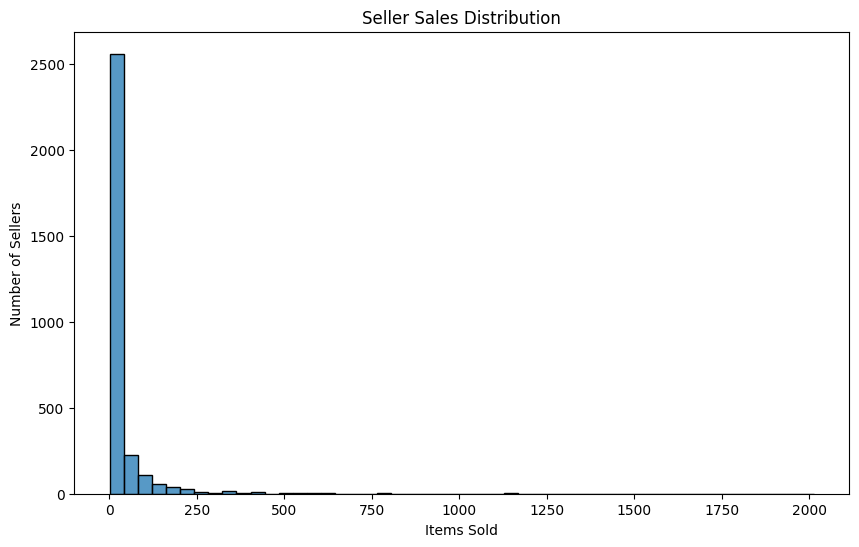

In [ ]:
# Create a visualization to make the pattern easier to interpret.
plt.figure(figsize=(10,6))

sns.histplot(
    seller_performance["items_sold"],
    bins=50
)

plt.title("Seller Sales Distribution")
plt.xlabel("Items Sold")
plt.ylabel("Number of Sellers")

plt.show()

In [ ]:
# Run this analysis step and display the result for interpretation.
filtered_sellers = seller_performance[
    seller_performance["items_sold"] < 200
]

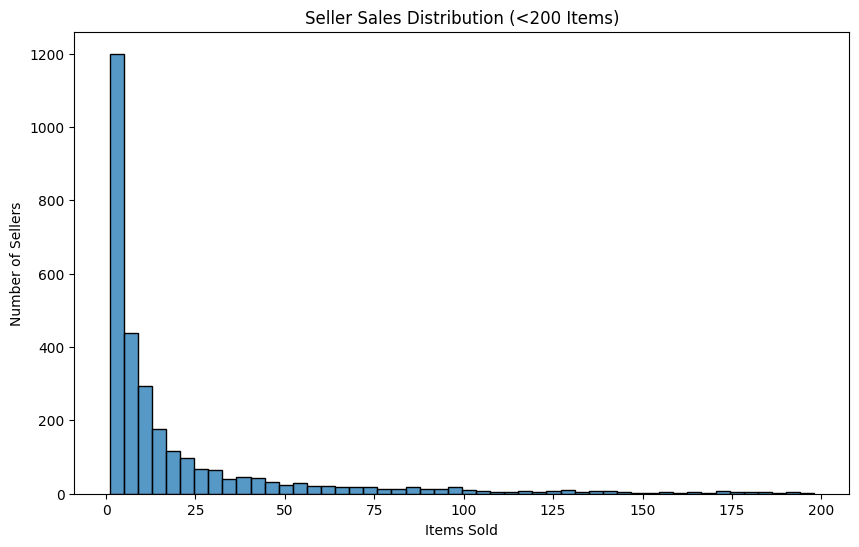

In [ ]:
# Create a visualization to make the pattern easier to interpret.
plt.figure(figsize=(10,6))

sns.histplot(
    filtered_sellers["items_sold"],
    bins=50
)

plt.title("Seller Sales Distribution (<200 Items)")
plt.xlabel("Items Sold")
plt.ylabel("Number of Sellers")

plt.show()

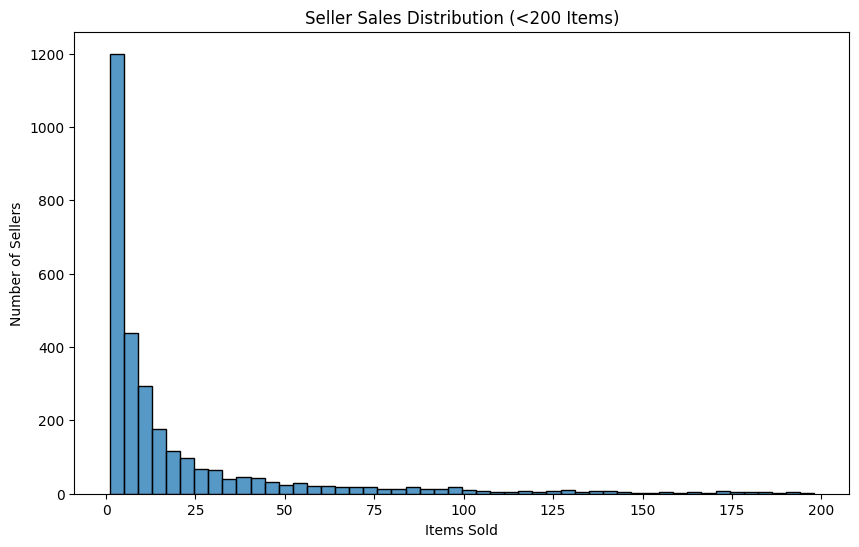

In [ ]:
# Create a visualization to make the pattern easier to interpret.
plt.figure(figsize=(10,6))

sns.histplot(
    filtered_sellers["items_sold"],
    bins=50
)

plt.title("Seller Sales Distribution (<200 Items)")
plt.xlabel("Items Sold")
plt.ylabel("Number of Sellers")

plt.show()

This Is A Huge Analytics Lesson
For skewed distributions:
Mean ≠ Typical
The mean can be distorted by extreme values.
Often:
Median ≈ Typical
is a better description.

The average (mean) seller sold 36 items, but the typical seller sold far less than 36 items because a small number of high-volume sellers pull the average upward.

In [ ]:
# Preview the first rows to understand the table structure and sample values.
seller_performance.head()

,seller_id,avg_review_score,late_delivery_rate,items_sold
0,0015a82c2db000af6aaaf3ae2ecb0532,3.666667,0.000000,3
1,001cca7ae9ae17fb1caed9dfb1094831,3.902542,0.050847,236
2,001e6ad469a905060d959994f1b41e4f,1.000000,0.000000,1
3,002100f778ceb8431b7a1020ff7ab48f,3.981818,0.163636,55
4,003554e2dce176b5555353e4f3555ac8,5.000000,0.000000,1


In [ ]:
#who are the market place gaints 
seller_performance.nlargest(10,'items_sold')[['seller_id','items_sold','avg_review_score','late_delivery_rate']]

,seller_id,items_sold,avg_review_score,late_delivery_rate
1232,6560211a19b47992c3666cc44a7e94c0,2014,3.908143,0.060576
878,4a3ca9315b744ce9f8e9374361493884,1962,3.803262,0.108053
368,1f50f920176fa81dab994f9023523100,1923,3.987259,0.092044
2476,cc419e0650a3c5ba77189a1882b7556a,1767,4.066403,0.058291
2638,da8622b14eb17ae2831f4ac5b9dab84a,1545,4.063754,0.070550
1820,955fee9216a65b617aa5c0531780ce60,1487,4.050437,0.078682
192,1025f0e2d44d7041d6cf58b6550e0bfa,1416,3.853107,0.091808
1532,7c67e1448b00f6e969d365cea6b010ab,1356,3.341445,0.094395
2831,ea8482cd71df3c1969d7b9473ff13abc,1196,3.952341,0.102007
1502,7a67c85e85bb2ce8582c35f2203ad736,1162,4.234509,0.057659


In [ ]:
# Calculate correlation to test whether two metrics move together.
seller_performance[
    ["items_sold", "avg_review_score", "late_delivery_rate"]
].corr()

,items_sold,avg_review_score,late_delivery_rate
items_sold,1.000000,0.018921,0.003581
avg_review_score,0.018921,1.000000,-0.254679
late_delivery_rate,0.003581,-0.254679,1.000000


<Axes: xlabel='items_sold', ylabel='avg_review_score'>

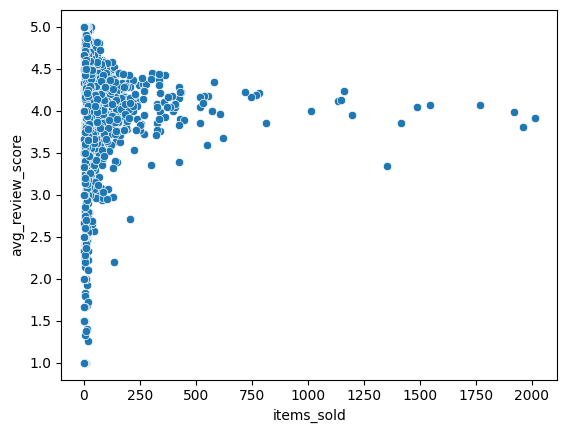

In [ ]:
# Run this analysis step and display the result for interpretation.
sns.scatterplot(
    data=seller_performance,
    x="items_sold",
    y="avg_review_score"
)

### Correlation Analysis: Seller Performance

The relationship between seller sales volume, customer satisfaction, and delivery performance was examined using correlation analysis.

#### Results

| Variables | Correlation |
|------------|------------|
| Items Sold vs Review Score | 0.019 |
| Items Sold vs Late Delivery Rate | 0.004 |
| Review Score vs Late Delivery Rate | -0.255 |

#### Findings

1. **Seller Size and Customer Satisfaction**
   - The correlation between items sold and average review score was approximately 0.
   - This suggests seller size has little to no relationship with customer satisfaction.
   - High-volume sellers do not appear to receive significantly better or worse reviews than smaller sellers.

2. **Seller Size and Delivery Performance**
   - The correlation between items sold and late delivery rate was also approximately 0.
   - Large sellers do not appear to experience meaningfully higher or lower delivery delays compared to smaller sellers.

3. **Delivery Performance and Customer Satisfaction**
   - A moderate negative correlation (-0.255) was observed between late delivery rate and review score.
   - Sellers with higher late delivery rates tend to receive lower customer ratings.
   - This suggests delivery reliability is an important driver of customer satisfaction.

#### Business Insight

Contrary to the initial hypothesis, seller size does not appear to influence customer satisfaction or delivery performance. The strongest relationship observed was between delivery reliability and review scores, indicating that reducing late deliveries may improve customer satisfaction more effectively than focusing on seller size or sales volume.

In [ ]:
# Run this analysis step and display the result for interpretation.
order_items_df.head(1)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29


In [ ]:
#seller revenue
seller_revenue=(order_items_df.groupby('seller_id')['price'].sum().reset_index())

In [ ]:
# Run this analysis step and display the result for interpretation.
seller_revenue.head(2)

,seller_id,price
0,0015a82c2db000af6aaaf3ae2ecb0532,2685.00
1,001cca7ae9ae17fb1caed9dfb1094831,25080.03


In [ ]:
# Merge related tables to combine business metrics needed for this analysis.
seller_performance = pd.merge(
    seller_performance,
    seller_revenue,
    on="seller_id",
    how="left"
)

seller_performance = seller_performance.rename(
    columns={"price": "total_revenue"}
)

In [ ]:
# Generate summary statistics to understand distribution, skewness, and outliers.
seller_performance["total_revenue"].describe()

count      3090.000000
mean       4396.111942
std       13932.385669
min           3.500000
25%         209.100000
50%         822.030000
75%        3281.245000
max      229472.630000
Name: total_revenue, dtype: float64

### Seller Revenue Distribution

Seller revenue is extremely right-skewed.

Key observations:

- Average seller revenue was 4,396.
- Median seller revenue was only 822.
- The highest revenue-generating seller produced 229,473 in sales.
- Revenue variability was very high (std = 13,932).

The large gap between the mean and median indicates that a relatively small number of sellers generate a disproportionately large share of marketplace revenue.

### Business Insight

Revenue concentration appears even stronger than sales volume concentration. A small number of high-performing sellers likely account for a significant portion of total marketplace revenue, suggesting potential dependence on a relatively small group of sellers.

In [ ]:
#I would visualize the revenue distribution and then do a Pareto (80/20) analysis to answer:
#"What percentage of sellers generate 80% of the revenue?"
pareto_df = seller_performance.sort_values(
    "total_revenue",
    ascending=False
).reset_index(drop=True)

pareto_df.head()

,seller_id,avg_review_score,late_delivery_rate,items_sold,total_revenue
0,4869f7a5dfa277a7dca6462dcf3b52b2,4.122822,0.114111,1148,229472.63
1,53243585a1d6dc2643021fd1853d8905,4.075980,0.036765,408,222776.05
2,4a3ca9315b744ce9f8e9374361493884,3.803262,0.108053,1962,200472.92
3,fa1c13f2614d7b5c4749cbc52fecda94,4.340206,0.096220,582,194042.03
4,7c67e1448b00f6e969d365cea6b010ab,3.341445,0.094395,1356,187923.89


In [ ]:
#who are the market place gaints 
seller_performance.nlargest(5,'items_sold')[['seller_id','items_sold','avg_review_score','late_delivery_rate']]

,seller_id,items_sold,avg_review_score,late_delivery_rate
1232,6560211a19b47992c3666cc44a7e94c0,2014,3.908143,0.060576
878,4a3ca9315b744ce9f8e9374361493884,1962,3.803262,0.108053
368,1f50f920176fa81dab994f9023523100,1923,3.987259,0.092044
2476,cc419e0650a3c5ba77189a1882b7556a,1767,4.066403,0.058291
2638,da8622b14eb17ae2831f4ac5b9dab84a,1545,4.063754,0.070550


In [ ]:
# calculate Revenue contribution 
pareto_df["cumulative_revenue"] = (
    pareto_df["total_revenue"].cumsum()
)

pareto_df["cumulative_pct"] = (
    pareto_df["cumulative_revenue"]
    / pareto_df["total_revenue"].sum()
)

In [ ]:
# Run this analysis step and display the result for interpretation.
top_80 = pareto_df[
    pareto_df["cumulative_pct"] <= 0.80
]

In [ ]:
# Preview the first rows to understand the table structure and sample values.
pareto_df.head()

,seller_id,avg_review_score,late_delivery_rate,items_sold,total_revenue,cumulative_revenue,cumulative_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,4.122822,0.114111,1148,229472.63,229472.63,0.016893
1,53243585a1d6dc2643021fd1853d8905,4.075980,0.036765,408,222776.05,452248.68,0.033293
2,4a3ca9315b744ce9f8e9374361493884,3.803262,0.108053,1962,200472.92,652721.60,0.048051
3,fa1c13f2614d7b5c4749cbc52fecda94,4.340206,0.096220,582,194042.03,846763.63,0.062335
4,7c67e1448b00f6e969d365cea6b010ab,3.341445,0.094395,1356,187923.89,1034687.52,0.076170


In [ ]:
# Run this analysis step and display the result for interpretation.
pareto_df[pareto_df["cumulative_pct"] >= 0.80].head(1)

,seller_id,avg_review_score,late_delivery_rate,items_sold,total_revenue,cumulative_revenue,cumulative_pct
542,02ecc2a19303f05e59ce133fd923fff7,4.541667,0.0,24,5264.19,10869374.45,0.800161


In [ ]:
# Run this analysis step and display the result for interpretation.
(542 + 1) / 3090 * 100

17.57281553398058

In [ ]:
# does most items seller generate the highest revenue 
seller_performance.nlargest(
    10,
    "total_revenue"
)[
    ["seller_id", "items_sold", "total_revenue"]
]

,seller_id,items_sold,total_revenue
854,4869f7a5dfa277a7dca6462dcf3b52b2,1148,229472.63
1010,53243585a1d6dc2643021fd1853d8905,408,222776.05
878,4a3ca9315b744ce9f8e9374361493884,1962,200472.92
3019,fa1c13f2614d7b5c4749cbc52fecda94,582,194042.03
1532,7c67e1448b00f6e969d365cea6b010ab,1356,187923.89
1557,7e93a43ef30c4f03f38b393420bc753a,339,176431.87
2638,da8622b14eb17ae2831f4ac5b9dab84a,1545,160236.57
1502,7a67c85e85bb2ce8582c35f2203ad736,1162,141745.53
192,1025f0e2d44d7041d6cf58b6550e0bfa,1416,138968.55
1820,955fee9216a65b617aa5c0531780ce60,1487,135171.70


In [ ]:
# Display the top records for the selected metric.
seller_performance.nlargest(
    10,
    "items_sold"
)[
    ["seller_id", "items_sold", "total_revenue"]
]

,seller_id,items_sold,total_revenue
1232,6560211a19b47992c3666cc44a7e94c0,2014,123304.83
878,4a3ca9315b744ce9f8e9374361493884,1962,200472.92
368,1f50f920176fa81dab994f9023523100,1923,106939.21
2476,cc419e0650a3c5ba77189a1882b7556a,1767,104288.42
2638,da8622b14eb17ae2831f4ac5b9dab84a,1545,160236.57
1820,955fee9216a65b617aa5c0531780ce60,1487,135171.70
192,1025f0e2d44d7041d6cf58b6550e0bfa,1416,138968.55
1532,7c67e1448b00f6e969d365cea6b010ab,1356,187923.89
2831,ea8482cd71df3c1969d7b9473ff13abc,1196,37177.52
1502,7a67c85e85bb2ce8582c35f2203ad736,1162,141745.53


In [ ]:
# Why isnt the top volume seller is not top revenue seller 
seller_performance["avg_revenue_per_item"] = (
    seller_performance["total_revenue"]
    / seller_performance["items_sold"]
)

In [ ]:
# Display the top records for the selected metric.
seller_performance.nlargest(
    10,
    "avg_revenue_per_item"
)[
    [
        "seller_id",
        "items_sold",
        "total_revenue",
        "avg_revenue_per_item"
    ]
]

,seller_id,items_sold,total_revenue,avg_revenue_per_item
2876,ee27a8f15b1dded4d213a468ba4eb391,1,6499.00,6499.000000
1075,585175ec331ea177fa47199e39a6170a,1,3549.00,3549.000000
2069,abe021b01ba992245271b9aa422032df,2,6720.00,3360.000000
1939,a00824eb9093d40e589b940ec45c4eb0,3,9399.97,3133.323333
2725,e2a1ac9bf33e5549a2a4f834e70df2f8,5,14999.45,2999.890000
2808,e908c0f3646e8b60375734a350d95d71,1,2951.00,2951.000000
2584,d63c73efd41eb002280e7ec831424edb,2,5598.00,2799.000000
238,1444c08e64d55fb3c25f0f09c07ffcf2,1,2749.00,2749.000000
42,039e6ad9dae79614493083e241147386,5,12925.00,2585.000000
1831,961dff0a659b4561334372337dd897d9,4,9946.00,2486.500000


In [ ]:
# Run this analysis step and display the result for interpretation.
pareto_df.head(10)

,seller_id,avg_review_score,late_delivery_rate,items_sold,total_revenue,cumulative_revenue,cumulative_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,4.122822,0.114111,1148,229472.63,229472.63,0.016893
1,53243585a1d6dc2643021fd1853d8905,4.075980,0.036765,408,222776.05,452248.68,0.033293
2,4a3ca9315b744ce9f8e9374361493884,3.803262,0.108053,1962,200472.92,652721.60,0.048051
3,fa1c13f2614d7b5c4749cbc52fecda94,4.340206,0.096220,582,194042.03,846763.63,0.062335
4,7c67e1448b00f6e969d365cea6b010ab,3.341445,0.094395,1356,187923.89,1034687.52,0.076170
5,7e93a43ef30c4f03f38b393420bc753a,4.206490,0.050147,339,176431.87,1211119.39,0.089158
6,da8622b14eb17ae2831f4ac5b9dab84a,4.063754,0.070550,1545,160236.57,1371355.96,0.100954
7,7a67c85e85bb2ce8582c35f2203ad736,4.234509,0.057659,1162,141745.53,1513101.49,0.111389
8,1025f0e2d44d7041d6cf58b6550e0bfa,3.853107,0.091808,1416,138968.55,1652070.04,0.121619
9,955fee9216a65b617aa5c0531780ce60,4.050437,0.078682,1487,135171.70,1787241.74,0.131570


### Pareto Analysis: Seller Revenue Concentration

A Pareto analysis was conducted to determine how revenue is distributed across sellers.

#### Findings

- Total sellers analyzed: 3,090
- Top 543 sellers generated 80% of total marketplace revenue.
- These sellers represent approximately 17.6% of all sellers.

#### Business Insight

The marketplace exhibits strong revenue concentration. A relatively small group of sellers is responsible for the majority of revenue generation.

Approximately 17.6% of sellers generate 80% of total revenue, closely aligning with the Pareto Principle (80/20 rule).

This suggests the marketplace may be highly dependent on a subset of top-performing sellers, making seller retention and operational support for these sellers strategically important.

### Revenue vs Sales Volume Analysis

A comparison between the highest-volume sellers and highest-revenue sellers revealed that sales volume does not necessarily translate into the highest revenue generation.

#### Key Findings

- The highest-volume seller sold 2,014 items and generated 123,305 in revenue.
- The highest-revenue seller sold only 1,148 items but generated 229,473 in revenue.
- Despite selling 866 fewer items, the top revenue seller generated approximately 106,169 more revenue.

#### Business Insight

This finding suggests that seller success can be achieved through different business strategies:

1. **Volume Strategy**
   - Selling a large number of lower-priced products.
   - Generates revenue through transaction volume.

2. **Value Strategy**
   - Selling fewer but higher-priced products.
   - Generates revenue through higher average revenue per item.

The analysis indicates that marketplace leaders in sales volume are not always marketplace leaders in revenue. Product pricing and product mix play a significant role in seller performance and revenue generation.
### Revenue per Item vs Total Revenue

A comparison between sellers with the highest average revenue per item and sellers with the highest total revenue revealed minimal overlap between the two groups.

This suggests that sellers offering the most expensive products are not necessarily the largest revenue generators.

Total revenue appears to be driven by a combination of sales volume and product value rather than either factor alone.

As a result, the marketplace contains distinct seller types:
- High-volume sellers
- Premium-product sellers
- Revenue leaders who balance both volume and product value

# Session Summary — Operational & Customer Analytics

## Topics Covered

### Data Understanding & Validation
- Investigated null values using business process logic
- Validated delivery-related missing values using `order_status`
- Checked duplicate rows and schema consistency
- Converted timestamp columns to proper datetime format

### Granularity & Relational Modeling
- Learned dataframe granularity concepts
- Identified one-to-many relationships between orders and order items
- Investigated how joins can duplicate rows
- Learned how `groupby()` transforms dataframe granularity

### Review Dataset Investigation
- Detected repeated `order_id` values inside reviews
- Investigated duplicate review behavior
- Found that some repeated reviews share the same score while others contain different scores
- Aggregated reviews safely to restore order-level granularity

### Operational Analytics
- Engineered `delivery_days`
- Engineered `late_delivery`
- Engineered `delay_days`
- Analyzed delivery performance and customer satisfaction relationship
- Found that late deliveries strongly reduce review scores

### Delivery Performance Findings
- Most deliveries arrive earlier than estimated
- Median delay is approximately 12 days early
- Extreme late deliveries still exist and likely damage customer experience

### Customer Analytics
- Created customer-level revenue aggregation
- Investigated customer spending distribution
- Identified strong right-skewed spending behavior
- Found evidence of high-value customer concentration

## Major Learning Concepts
- Granularity
- One-to-many relationships
- Safe joins
- Aggregation logic
- Feature engineering
- Operational KPI analysis
- Distribution interpretation
- Right-skewed behavior
- Business interpretation from data

# Executive Summary

## Customer Insights
- Customer spending is highly right-skewed.
- A small percentage of customers generate a large share of marketplace revenue.
- VIP customers contribute the most revenue but report lower satisfaction levels than other customer segments.

## Delivery Insights
- Most orders arrive before the estimated delivery date.
- Late deliveries are associated with lower review scores.
- Delivery reliability appears to be a key driver of customer satisfaction.

## Seller Insights
- Seller sales volume is highly concentrated.
- Seller revenue is even more concentrated than sales volume.
- Approximately 17.6% of sellers generate 80% of marketplace revenue.
- Seller size has little relationship with customer satisfaction or delivery performance.

## Marketplace Insights
- The highest-volume seller is not the highest-revenue seller.
- Sellers with the highest revenue per item are not necessarily the highest-revenue sellers.
- Revenue leaders typically balance both sales volume and product value.

## Strategic Recommendations
1. Improve delivery reliability to increase customer satisfaction.
2. Monitor VIP customer experience closely.
3. Prioritize retention of high-revenue sellers.
4. Support both high-volume and premium-product seller segments.
5. Monitor revenue concentration risk within the seller ecosystem.


# 21. Product Analysis

## Objective

The purpose of this section is to analyze product performance across the marketplace.

Key business questions:

1. Which products generate the most revenue?
2. Which products sell the most units?
3. Are the highest-selling products also the highest-revenue products?
4. Which product categories receive the highest and lowest customer ratings?
5. Which product categories experience the highest late-delivery rates?
6. What product-level insights can help improve marketplace performance?

---

### Business Importance

Understanding product performance helps identify:

- Revenue-driving products
- High-demand products
- Underperforming categories
- Customer satisfaction trends
- Operational challenges across product categories

These insights can support inventory planning, seller strategy, customer experience improvements, and marketplace growth initiatives.

## Analysis Framework

### Business Question
Which products and categories drive marketplace demand, revenue, and customer satisfaction?

### Why This Matters
Understanding product and category performance helps management optimize inventory, marketing investment, supplier relationships, and customer experience initiatives.

## Data Preparation

Before analyzing products, it is important to understand the granularity of the available datasets and identify the tables required for product-level analysis.

Key datasets:

- order_items_df
- products_df
- reviews_df
- orders_df

The analysis will begin by validating granularity and identifying the appropriate join strategy before calculating product performance metrics.

## Granularity Review

Before performing product-level analysis, it is important to confirm the granularity of each dataset and understand how the tables relate to one another.

### Dataset Granularity

| Dataset | Granularity |
|----------|----------|
| orders_df | 1 row = 1 order |
| order_items_df | 1 row = 1 item sold within an order |
| reviews_df | 1 row = 1 review per order |
| products_df | 1 row = 1 product |

### Key Relationships

- One order can contain multiple items.
- One product can appear in multiple orders.
- One seller can sell multiple products.
- Reviews are recorded at the order level rather than the product level.

### Analytical Consideration

Because reviews exist at the order level, any product-level review analysis requires careful interpretation. When joining reviews to products through order items, the same review may be associated with multiple products contained in the same order.

This does not create a technical issue in the merge process, but it should be acknowledged as a business limitation when interpreting product satisfaction metrics.

#check

In [ ]:
#check granularity Every product in catalog appears at;east once  sales data they are idetical 
print('Product Shape:',products_df.shape)
print('Unique Products:',products_df['product_id'].nunique())

Product Shape: (32951, 9)
Unique Products: 32951


In [ ]:
# Run this analysis step and display the result for interpretation.
print("Order Items shape:", order_items_df.shape)
print("Unique products in orders:",
      order_items_df["product_id"].nunique())

Order Items shape: (112650, 7)
Unique products in orders: 32951


### Product Catalog Coverage

The product catalog contains 32,951 unique products.

A comparison between the products catalog and order items dataset showed that all 32,951 products appeared in at least one customer order.

#### Findings

- Products in catalog: 32,951
- Products sold: 32,951
- Unsold products: 0

#### Business Insight

Every product in the catalog generated at least one sale during the observed period.

This indicates complete catalog utilization within the dataset and suggests that no products remained entirely inactive.

### Product Sales Analysis

To identify the marketplace's most popular products, the order items dataset was aggregated at the product level.

#### Methodology

- Grouped the dataset by product_id.
- Counted the number of times each product appeared in customer orders.
- Created a units_sold metric representing total product sales volume.

#### Resulting Granularity

After aggregation:

- 1 row = 1 product
- units_sold = total number of units sold

In [ ]:
#Which product sell the most 

product_sales = (
    order_items_df
    .groupby("product_id")
    .agg(
        units_sold=("product_id", "count")
    )
    .reset_index()
)

In [ ]:
# Aggregate records to calculate sales volume at the selected business level.
product_sales = (
    order_items_df
    .groupby("product_id")
    .agg(
        units_sold=("product_id", "count")
    )
    .reset_index()
)

product_sales["units_sold"].describe()

count    32951.000000
mean         3.418713
std         10.619709
min          1.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        527.000000
Name: units_sold, dtype: float64

### Product Sales Distribution

Product sales volume is highly right-skewed.

#### Findings

- Average product sales: 3.42 units
- Median product sales: 1 unit
- 75% of products sold 3 units or fewer
- Highest-selling product sold 527 units

#### Business Insight

The marketplace exhibits a long-tail sales distribution.

Most products generate very few sales, while a small number of products account for a disproportionately large share of sales volume.

This suggests that marketplace demand is concentrated among a relatively small group of highly popular products.

In [ ]:
#Identify marketplace strat products 
product_sales.nlargest(10, "units_sold")

,product_id,units_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,527
19742,99a4788cb24856965c36a24e339b6058,488
8613,422879e10f46682990de24d770e7f83d,484
7364,389d119b48cf3043d311335e499d9c6b,392
7079,368c6c730842d78016ad823897a372db,388
10840,53759a2ecddad2bb87a079a1f1519f73,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,343
10867,53b36df67ebb7c41585e8d54d6772e08,323
2794,154e7e31ebfa092203795c972e5804a6,281
8051,3dd2a17168ec895c781a9191c1e95ad7,274


### Top-Selling Products

Analysis of product sales volume revealed a highly concentrated demand pattern.

#### Findings

- The highest-selling product sold 527 units.
- The second-highest-selling product sold 488 units.
- The third-highest-selling product sold 484 units.
- The fourth-highest-selling product sold 393 units.
- In contrast, the median product sold only 1 unit.

#### Business Insight

Product demand is highly concentrated among a small number of products.

While most products generate very limited sales volume, a small group of highly popular products drives a significant portion of marketplace activity.

This pattern is consistent with a long-tail marketplace, where a few products achieve very high demand while the majority of products remain low-volume sellers.

In [ ]:
#what product catogory thes top product belog to 
product_sales = product_sales.merge(
    products_df[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

product_sales.nlargest(
    10,
    "units_sold"
)[
    ["product_id", "product_category_name", "units_sold"]
]

,product_id,product_category_name,units_sold
22112,aca2eb7d00ea1a7b8ebd4e68314663af,moveis_decoracao,527
19742,99a4788cb24856965c36a24e339b6058,cama_mesa_banho,488
8613,422879e10f46682990de24d770e7f83d,ferramentas_jardim,484
7364,389d119b48cf3043d311335e499d9c6b,ferramentas_jardim,392
7079,368c6c730842d78016ad823897a372db,ferramentas_jardim,388
10840,53759a2ecddad2bb87a079a1f1519f73,ferramentas_jardim,373
27039,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,343
10867,53b36df67ebb7c41585e8d54d6772e08,relogios_presentes,323
2794,154e7e31ebfa092203795c972e5804a6,beleza_saude,281
8051,3dd2a17168ec895c781a9191c1e95ad7,informatica_acessorios,274


### Top-Selling Products by Units Sold

The marketplace's highest-selling products were identified by aggregating sales volume at the product level.

#### Findings

- The top-selling product sold 527 units.
- Several products sold more than 300 units.
- The Garden Tools category (ferramentas_jardim) appeared 4 times among the top 10 best-selling products.
- Computer Accessories (informatica_acessorios) appeared 2 times among the top 10 best-selling products.

#### Business Insight

The concentration of multiple Garden Tools products among the top-selling items suggests strong customer demand within this category.

However, category-level aggregation is required to determine whether these categories consistently outperform others across the marketplace.

category_sales = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        units_sold=("product_id", "count")
    )
    .reset_index()
)

category_sales.nlargest(
    10,
    "units_sold"
)

In [ ]:
# Aggregate records to calculate sales volume at the selected business level.
category_sales = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        units_sold=("product_id", "count")
    )
    .reset_index()
)

category_sales.nlargest(
    10,
    "units_sold"
)

,product_category_name,units_sold
13,cama_mesa_banho,11115
11,beleza_saude,9670
32,esporte_lazer,8641
54,moveis_decoracao,8334
44,informatica_acessorios,7827
72,utilidades_domesticas,6964
66,relogios_presentes,5991
70,telefonia,4545
40,ferramentas_jardim,4347
8,automotivo,4235


## Category-Level Demand Analysis

While product-level analysis identifies individual best-selling products, category-level analysis provides a broader view of marketplace demand.

The objective of this section is to determine which product categories generate the highest sales volume and identify categories that consistently drive marketplace activity.

### Methodology

1. Merge order_items_df with products_df using product_id.
2. Assign each sold item to its corresponding product category.
3. Aggregate sales volume at the category level.
4. Rank categories based on total units sold.

### Resulting Granularity

After aggregation:

- 1 row = 1 product category
- units_sold = total items sold within that category

In [ ]:
# Aggregate records to calculate sales volume at the selected business level.
category_sales = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        units_sold=("product_id", "count")
    )
    .reset_index()
)

category_sales.nlargest(
    10,
    "units_sold"
)

,product_category_name,units_sold
13,cama_mesa_banho,11115
11,beleza_saude,9670
32,esporte_lazer,8641
54,moveis_decoracao,8334
44,informatica_acessorios,7827
72,utilidades_domesticas,6964
66,relogios_presentes,5991
70,telefonia,4545
40,ferramentas_jardim,4347
8,automotivo,4235


### Category-Level Demand Analysis

Sales volume was aggregated at the product-category level to identify the marketplace's strongest demand categories.

#### Findings

Top categories by units sold:

1. Bed, Table & Bath (bed_bath_table) – 11,115 units
2. Beauty & Health (health_beauty) – 9,670 units
3. Sports & Leisure (esporte_lazer) – 8,641 units
4. Furniture & Decoration (moveis_decoracao) – 8,334 units
5. Computer Accessories (informatica_acessorios) – 7,827 units

#### Business Insight

Demand is not concentrated within a single category. Instead, several categories contribute significantly to marketplace activity.

An interesting observation is that Garden Tools (ferramentas_jardim) appeared multiple times among the top-selling individual products but ranked only ninth at the category level.

This suggests that a small number of highly successful products may drive category performance, while categories such as Bed, Table & Bath achieve leadership through broader and more consistent demand across many products.

In [ ]:
# Generate summary statistics to understand distribution, skewness, and outliers.
category_sales["units_sold"].describe()

count       73.000000
mean      1521.191781
std       2582.713020
min          2.000000
25%         76.000000
50%        278.000000
75%       1691.000000
max      11115.000000
Name: units_sold, dtype: float64

### Category Sales Distribution

Category sales volume is strongly right-skewed.

#### Findings

- Average category sales volume was 1,521 units.
- Median category sales volume was only 278 units.
- The largest category sold 11,115 units.
- Sales variability across categories was high (std = 2,583).

#### Business Insight

Demand is unevenly distributed across product categories.

While many categories generate relatively low sales volume, a small number of categories account for a disproportionate share of marketplace demand.

This suggests that marketplace growth and inventory planning efforts may benefit from prioritizing high-demand categories while evaluating the strategic value of low-volume categories.

In [ ]:
# Aggregate revenue metrics to identify the strongest financial contributors.
category_revenue = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        total_revenue=("price", "sum")
    )
    .reset_index()
)

category_revenue.nlargest(
    10,
    "total_revenue"
)

,product_category_name,total_revenue
11,beleza_saude,1258681.34
66,relogios_presentes,1205005.68
13,cama_mesa_banho,1036988.68
32,esporte_lazer,988048.97
44,informatica_acessorios,911954.32
54,moveis_decoracao,729762.49
26,cool_stuff,635290.85
72,utilidades_domesticas,632248.66
8,automotivo,592720.11
40,ferramentas_jardim,485256.46


### Category Revenue Analysis

Revenue was aggregated at the product-category level to identify the marketplace's most valuable categories.

#### Findings

Top categories by revenue:

1. Beauty & Health (health_beauty) – 1.26M
2. Watches & Gifts (relogios_presentes) – 1.21M
3. Bed, Table & Bath (bed_bath_table) – 1.04M
4. Sports & Leisure (esporte_lazer) – 0.99M
5. Computer Accessories (informatica_acessorios) – 0.91M

#### Business Insight

Category rankings differ when evaluated by revenue instead of sales volume.

A notable example is Watches & Gifts (relogios_presentes), which ranked seventh in units sold but second in total revenue.

This suggests that product value plays a major role in revenue generation and that categories with fewer sales can outperform higher-volume categories when average selling prices are significantly higher.

### Key Learning

Across sellers, products, and categories, sales volume alone does not fully explain business performance. Revenue is influenced by both demand and product value.

### Cross-Level Revenue Insight

A recurring pattern emerged across sellers, products, and categories:

- Highest sales volume did not necessarily produce the highest revenue.
- Higher-value products were often able to generate substantial revenue despite lower sales volume.

This pattern was observed at multiple levels of analysis:

1. Seller Level
2. Product Level
3. Category Level

The findings suggest that revenue generation depends on both demand and product value rather than sales volume alone.

## Category Name Translation

The original product categories are stored in Portuguese.

To improve readability and make the analysis more accessible to business stakeholders, category names will be translated into English using the category translation dataset.

This enhancement does not affect any calculations and is used solely for presentation and interpretation purposes.

In [ ]:
# Preview the first rows to understand the table structure and sample values.
product_category_name_translation_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [ ]:
# Merge related tables to combine business metrics needed for this analysis.
category_sales = category_sales.merge(
    product_category_name_translation_df,
    on="product_category_name",
    how="left"
)

In [ ]:
#check cagetorgy sales names after mergae 
category_sales.isnull().sum()

product_category_name            0
units_sold                       0
product_category_name_english    2
dtype: int64

In [ ]:
#fill the name in english 
category_sales["product_category_name_english"] = (
    category_sales["product_category_name_english"]
    .fillna(category_sales["product_category_name"])
)

In [ ]:
# Display the top records for the selected metric.
category_sales.nlargest(
    10,
    "units_sold"
)[
    [
        "product_category_name_english",
        "units_sold"
    ]
]

,product_category_name_english,units_sold
13,bed_bath_table,11115
11,health_beauty,9670
32,sports_leisure,8641
54,furniture_decor,8334
44,computers_accessories,7827
72,housewares,6964
66,watches_gifts,5991
70,telephony,4545
40,garden_tools,4347
8,auto,4235


## Category Satisfaction Analysis

Sales volume and revenue indicate marketplace demand and financial performance, but customer satisfaction provides insight into the customer experience.

The objective of this section is to identify which product categories receive the highest and lowest review scores.

### Business Importance

Understanding category-level satisfaction helps identify:

- Categories that consistently exceed customer expectations.
- Categories that may require quality improvements.
- Potential relationships between customer satisfaction, sales volume, and revenue.

In [ ]:
#category reviews analysis 
category_reviews = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        reviews_df[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        avg_review_score=("review_score", "mean"),
        review_count=("review_score", "count")
    )
    .reset_index()
)

In [ ]:
#Translate Category names
category_reviews = category_reviews.merge(
    product_category_name_translation_df,
    on="product_category_name",
    how="left"
)

In [ ]:
# Preview the first rows to understand the table structure and sample values.
category_reviews.head()

,product_category_name,avg_review_score,review_count,product_category_name_english
0,agro_industria_e_comercio,4.000000,212,agro_industry_and_commerce
1,alimentos,4.218182,495,food
2,alimentos_bebidas,4.315412,279,food_drink
3,artes,3.937198,207,art
4,artes_e_artesanato,4.125000,24,arts_and_craftmanship


In [ ]:
#top 10 category reviews score 
category_reviews.nlargest(
    10,
    "avg_review_score"
)

,product_category_name,avg_review_score,review_count,product_category_name_english
17,cds_dvds_musicais,4.642857,14,cds_dvds_musicals
37,fashion_roupa_infanto_juvenil,4.500000,8,fashion_childrens_clothes
48,livros_interesse_geral,4.446266,549,books_general_interest
22,construcao_ferramentas_ferramentas,4.444444,99,costruction_tools_tools
41,flores,4.419355,31,flowers
47,livros_importados,4.400000,60,books_imported
49,livros_tecnicos,4.368421,266,books_technical
2,alimentos_bebidas,4.315412,279,food_drink
50,malas_acessorios,4.315257,1088,luggage_accessories
64,portateis_casa_forno_e_cafe,4.302632,76,small_appliances_home_oven_and_coffee


In [ ]:
# Display the top records for the selected metric.
category_reviews.nlargest(
    10,
    "avg_review_score"
)[
    [
        "product_category_name_english",
        "avg_review_score",
        "review_count"
    ]
]

,product_category_name_english,avg_review_score,review_count
17,cds_dvds_musicals,4.642857,14
37,fashion_childrens_clothes,4.500000,8
48,books_general_interest,4.446266,549
22,costruction_tools_tools,4.444444,99
41,flowers,4.419355,31
47,books_imported,4.400000,60
49,books_technical,4.368421,266
2,food_drink,4.315412,279
50,luggage_accessories,4.315257,1088
64,small_appliances_home_oven_and_coffee,4.302632,76


In [ ]:
# Run this analysis step and display the result for interpretation.
category_reviews_filtered = category_reviews[
    category_reviews["review_count"] >= 100
]

In [ ]:
# Display the top records for the selected metric.
category_reviews_filtered.nlargest(
    10,
    "avg_review_score"
)[
    [
        "product_category_name_english",
        "avg_review_score",
        "review_count"
    ]
]

,product_category_name_english,avg_review_score,review_count
48,books_general_interest,4.446266,549
49,books_technical,4.368421,266
2,food_drink,4.315412,279
50,luggage_accessories,4.315257,1088
34,fashion_shoes,4.233716,261
1,food,4.218182,495
59,stationery,4.193857,2507
63,pet_shop,4.185147,1939
61,computers,4.175000,200
28,home_appliances,4.172457,806


In [ ]:
# Display the lowest records for the selected metric.
category_reviews_filtered.nsmallest(
    10,
    "avg_review_score"
)[
    [
        "product_category_name_english",
        "avg_review_score",
        "review_count"
    ]
]

,product_category_name_english,avg_review_score,review_count
55,office_furniture,3.493183,1687
38,fashion_male_clothing,3.641221,131
71,fixed_telephony,3.683206,262
7,audio,3.825485,361
14,home_confort,3.829885,435
25,construction_tools_safety,3.844560,193
13,bed_bath_table,3.895663,11137
54,furniture_decor,3.903493,8331
57,furniture_living_room,3.904382,502
44,computers_accessories,3.930819,7849


In [ ]:
# Display the lowest records for the selected metric.
category_reviews.nsmallest(
    10,
    "avg_review_score"
)[
    [
        "product_category_name_english",
        "avg_review_score",
        "review_count"
    ]
]

,product_category_name_english,avg_review_score,review_count
67,security_and_services,2.500000,2
42,diapers_and_hygiene,3.256410,39
65,NaN,3.266667,15
60,NaN,3.333333,9
55,office_furniture,3.493183,1687
15,home_comfort_2,3.629630,27
38,fashion_male_clothing,3.641221,131
71,fixed_telephony,3.683206,262
5,party_supplies,3.767442,43
36,fashio_female_clothing,3.780000,50


### Category Satisfaction Analysis

Category review scores were analyzed using categories with at least 100 reviews to ensure reliable comparisons.

#### Highest-Rated Categories

- Books (General Interest) – 4.45
- Books (Technical) – 4.37
- Food & Drink – 4.32
- Luggage Accessories – 4.32
- Fashion Shoes – 4.23

#### Lowest-Rated Categories

- Office Furniture – 3.49
- Fashion Male Clothing – 3.64
- Fixed Telephony – 3.68
- Audio – 3.83
- Home Comfort – 3.83

#### Business Insight

Customer satisfaction varies meaningfully across categories.

Office Furniture stands out as the lowest-rated category despite receiving a substantial number of reviews, suggesting a consistent customer experience issue rather than random variation.

Additionally, Bed, Bath & Table remains the marketplace's highest-volume category while maintaining a below-average review score, indicating a potential opportunity to improve customer satisfaction within a strategically important category.

In [ ]:
#about the low rating count lets check unit sold 
category_performance = (
    category_reviews_filtered
    .merge(
        category_sales[
            [
                "product_category_name",
                "units_sold"
            ]
        ],
        on="product_category_name",
        how="left"
    )
)

category_performance[
    [
        "product_category_name_english",
        "avg_review_score",
        "review_count",
        "units_sold"
    ]
].sort_values(
    "avg_review_score"
).head(10)

,product_category_name_english,avg_review_score,review_count,units_sold
40,office_furniture,3.493183,1687,1691
28,fashion_male_clothing,3.641221,131,132
50,fixed_telephony,3.683206,262,264
5,audio,3.825485,361,364
12,home_confort,3.829885,435,434
19,construction_tools_safety,3.844560,193,194
11,bed_bath_table,3.895663,11137,11115
39,furniture_decor,3.903493,8331,8334
42,furniture_living_room,3.904382,502,503
32,computers_accessories,3.930819,7849,7827


In [ ]:
# Run this analysis step and display the result for interpretation.
category_performance["review_rate"] = (
    category_performance["review_count"]
    / category_performance["units_sold"]
)

In [ ]:
# Sort results to rank records by the selected metric.
category_performance[
    [
        "product_category_name_english",
        "units_sold",
        "review_count",
        "review_rate"
    ]
].sort_values(
    "review_rate"
)

,product_category_name_english,units_sold,review_count,review_rate
4,christmas_supplies,153,146,0.954248
1,food,510,495,0.970588
17,construction_tools_lights,304,296,0.973684
14,air_conditioning,297,292,0.983165
44,computers,203,200,0.985222
48,signaling_and_security,199,197,0.989950
3,art,209,207,0.990431
15,consoles_games,1137,1127,0.991205
5,audio,364,361,0.991758
29,fashion_underwear_beach,131,130,0.992366


## Review Participation Analysis

Before interpreting low review counts as low customer engagement, it is important to determine whether review volume is primarily driven by sales volume.

The objective of this analysis is to compare review counts against units sold and calculate the review participation rate for each category.

### Business Question

Are low review counts caused by:

1. Low sales volume?
2. Lower customer willingness to leave reviews?

In [ ]:
# Run this analysis step and display the result for interpretation.
category_performance["review_rate"] = (
    category_performance["review_count"]
    / category_performance["units_sold"]
)

In [ ]:
# Generate summary statistics to understand distribution, skewness, and outliers.
category_performance["review_rate"].describe()

count    52.000000
mean      0.995262
std       0.011266
min       0.954248
25%       0.992620
50%       0.995352
75%       0.998419
max       1.045396
Name: review_rate, dtype: float64

In [ ]:
# Display the top records for the selected metric.
category_performance.nlargest(
    10,
    "review_rate"
)[
    [
        "product_category_name_english",
        "units_sold",
        "review_count",
        "review_rate"
    ]
]

,product_category_name_english,units_sold,review_count,review_rate
21,home_appliances,771,806,1.045396
41,furniture_bedroom,109,110,1.009174
18,costruction_tools_garden,238,240,1.008403
26,fashion_bags_accessories,2031,2039,1.003939
2,food_drink,278,279,1.003597
32,computers_accessories,7827,7849,1.002811
12,home_confort,434,435,1.002304
11,bed_bath_table,11115,11137,1.001979
45,perfumery,3419,3421,1.000585
0,agro_industry_and_commerce,212,212,1.000000


In [ ]:
# Display the lowest records for the selected metric.
category_performance.nsmallest(
    10,
    "review_rate"
)[
    [
        "product_category_name_english",
        "units_sold",
        "review_count",
        "review_rate"
    ]
]

,product_category_name_english,units_sold,review_count,review_rate
4,christmas_supplies,153,146,0.954248
1,food,510,495,0.970588
17,construction_tools_lights,304,296,0.973684
14,air_conditioning,297,292,0.983165
44,computers,203,200,0.985222
48,signaling_and_security,199,197,0.989950
3,art,209,207,0.990431
15,consoles_games,1137,1127,0.991205
5,audio,364,361,0.991758
29,fashion_underwear_beach,131,130,0.992366


### Review Participation Observation

Review participation rates were extremely consistent across categories.

The average review-to-unit ratio was approximately 1.0, indicating that differences in review counts were primarily driven by differences in sales volume rather than category-specific review behavior.

A small number of categories exhibited review-to-unit ratios slightly above 1.0. This is likely caused by the analytical join structure, where order-level reviews are associated with multiple products when an order contains more than one item.

As a result, review counts should be interpreted as analytical observations rather than exact counts of unique customer reviews.

## Category Delivery Performance Analysis

Customer satisfaction may be influenced by operational factors such as delivery performance.

The objective of this section is to identify categories with the highest late-delivery rates and evaluate whether delivery issues may contribute to lower customer satisfaction.

### Business Question

Do categories with lower review scores also experience higher late-delivery rates?

In [ ]:
#create category delivery by merging oder_items,order and prdocuts 
category_delivery = (
    order_items_df
    .merge(
        products_df[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        orders_df[
            ["order_id", "late_delivery"]
        ],
        on="order_id",
        how="left"
    )
    .groupby("product_category_name")
    .agg(
        late_delivery_rate=("late_delivery", "mean")
    )
    .reset_index()
)

In [ ]:
#add english name 
category_delivery = category_delivery.merge(
    product_category_name_translation_df,
    on="product_category_name",
    how="left"
)

In [ ]:
# Generate summary statistics to understand distribution, skewness, and outliers.
category_delivery['late_delivery_rate'].describe()

count    73.000000
mean      0.067854
std       0.029989
min       0.000000
25%       0.055276
50%       0.069444
75%       0.081126
max       0.166667
Name: late_delivery_rate, dtype: float64

In [ ]:
#check the top 10 late delivery rate 
category_delivery.nlargest(
    10,
    "late_delivery_rate"
)

,product_category_name,late_delivery_rate,product_category_name_english
15,casa_conforto_2,0.166667,home_comfort_2
52,moveis_colchao_e_estofado,0.131579,furniture_mattress_and_upholstery
7,audio,0.126374,audio
39,fashion_underwear_e_moda_praia,0.122137,fashion_underwear_beach
6,artigos_de_natal,0.117647,christmas_supplies
49,livros_tecnicos,0.108614,books_technical
14,casa_conforto,0.101382,home_confort
23,construcao_ferramentas_iluminacao,0.098684,construction_tools_lights
30,eletronicos,0.096133,electronics
1,alimentos,0.096078,food


In [ ]:
# merge category preformance and delivery to check correlation between review score and late delivery 
category_master = (
    category_performance
    .merge(
        category_delivery[
            [
                "product_category_name",
                "late_delivery_rate"
            ]
        ],
        on="product_category_name",
        how="left"
    )
)

In [ ]:
# Calculate correlation to test whether two metrics move together.
category_master[
    [
        "avg_review_score",
        "late_delivery_rate"
    ]
].corr()

,avg_review_score,late_delivery_rate
avg_review_score,1.00000,-0.06044
late_delivery_rate,-0.06044,1.00000


### Delivery Performance and Customer Satisfaction

A correlation analysis was conducted to evaluate whether category-level customer satisfaction is associated with delivery performance.

#### Result

Correlation between:

- Average Review Score
- Late Delivery Rate

was:

r = -0.060

#### Business Insight

The relationship between customer satisfaction and late delivery rates was negligible.

While some categories experienced higher late-delivery rates, delivery performance does not appear to be a major driver of category-level review scores.

This suggests that other factors, such as product quality, product expectations, assembly complexity, or product condition upon arrival, may play a more significant role in shaping customer satisfaction.

## Category Performance Matrix

This section combines category-level sales volume, revenue, customer satisfaction, and delivery performance into one master table.

The purpose is to identify which categories are strategically important based on multiple business metrics rather than evaluating each metric separately.

### Business Question

Which product categories are the strongest opportunities, risks, or growth drivers when considering demand, revenue, satisfaction, and delivery together?

In [ ]:
# Create a master category performance table by combining
# sales volume, revenue, review score, and late-delivery rate
category_master = (
    
    # Start with category sales volume and English category name
    category_sales[
        [
            "product_category_name",
            "product_category_name_english",
            "units_sold"
        ]
    ]
    
    # Add total revenue by category
    .merge(
        category_revenue[
            [
                "product_category_name",
                "total_revenue"
            ]
        ],
        on="product_category_name",
        how="left"
    )
    
    # Add average review score by category
    .merge(
        category_reviews[
            [
                "product_category_name",
                "avg_review_score"
            ]
        ],
        on="product_category_name",
        how="left"
    )
    
    # Add late-delivery rate by category
    .merge(
        category_delivery[
            [
                "product_category_name",
                "late_delivery_rate"
            ]
        ],
        on="product_category_name",
        how="left"
    )
)

# Preview the combined category performance table
category_master.head()

,product_category_name,product_category_name_english,units_sold,total_revenue,avg_review_score,late_delivery_rate
0,agro_industria_e_comercio,agro_industry_and_commerce,212,72530.47,4.000000,0.042453
1,alimentos,food,510,29393.41,4.218182,0.096078
2,alimentos_bebidas,food_drink,278,15179.48,4.315412,0.061151
3,artes,art,209,24202.64,3.937198,0.071770
4,artes_e_artesanato,arts_and_craftmanship,24,1814.01,4.125000,0.083333


In [ ]:
# Display the top records for the selected metric.
category_master.nlargest(
    10,
    "total_revenue"
)

,product_category_name,product_category_name_english,units_sold,total_revenue,avg_review_score,late_delivery_rate
11,beleza_saude,health_beauty,9670,1258681.34,4.142768,0.088728
66,relogios_presentes,watches_gifts,5991,1205005.68,4.019160,0.080955
13,cama_mesa_banho,bed_bath_table,11115,1036988.68,3.895663,0.082771
32,esporte_lazer,sports_leisure,8641,988048.97,4.107986,0.072330
44,informatica_acessorios,computers_accessories,7827,911954.32,3.930819,0.075891
54,moveis_decoracao,furniture_decor,8334,729762.49,3.903493,0.082553
26,cool_stuff,cool_stuff,3796,635290.85,4.146341,0.066122
72,utilidades_domesticas,housewares,6964,632248.66,4.055019,0.063326
8,automotivo,auto,4235,592720.11,4.065512,0.080992
40,ferramentas_jardim,garden_tools,4347,485256.46,4.042735,0.078215


### Category Performance Matrix Summary

A master category performance table was created to compare sales volume, revenue, customer satisfaction, and delivery performance together.

#### Key Findings

- Health & Beauty generated the highest revenue, with 1.26M in sales and a strong average review score of 4.14.
- Watches & Gifts ranked second in revenue despite lower sales volume than several other categories, showing the impact of higher product value.
- Bed Bath & Table ranked first in units sold and third in revenue, but had one of the lowest review scores among top-revenue categories.
- Furniture & Decor also showed high sales volume and revenue but relatively low customer satisfaction.
- Cool Stuff performed well across multiple dimensions, with strong revenue, good satisfaction, and below-average late-delivery rate.

#### Business Insight

The top categories show different performance profiles.

Some categories are revenue leaders because of high sales volume, while others generate strong revenue through higher-value products. However, several high-volume categories also have weaker customer satisfaction, suggesting opportunities for improvement in customer experience.

Bed Bath & Table and Furniture & Decor are especially important because they combine high marketplace activity with below-average satisfaction.

In [ ]:
# Review the distribution of category revenue
category_master["total_revenue"].describe()

count    7.300000e+01
mean     1.837275e+05
std      3.010151e+05
min      2.832900e+02
25%      7.528410e+03
50%      4.632837e+04
75%      1.914989e+05
max      1.258681e+06
Name: total_revenue, dtype: float64

In [ ]:
# Review the distribution of category review scores
category_master["avg_review_score"].describe()

count    73.000000
mean      4.020371
std       0.314879
min       2.500000
25%       3.937198
50%       4.054167
75%       4.172457
max       4.642857
Name: avg_review_score, dtype: float64

In [ ]:
# Review the distribution of category revenue
category_master["total_revenue"].describe()

count    7.300000e+01
mean     1.837275e+05
std      3.010151e+05
min      2.832900e+02
25%      7.528410e+03
50%      4.632837e+04
75%      1.914989e+05
max      1.258681e+06
Name: total_revenue, dtype: float64

In [ ]:
# Classify categories based on strategic business performance
def classify_category(row):
    if row["total_revenue"] >= category_master["total_revenue"].quantile(0.75) and row["avg_review_score"] >= 4.1:
        return "Star"
    elif row["total_revenue"] >= category_master["total_revenue"].quantile(0.75) and row["avg_review_score"] < 4.1:
        return "Opportunity"
    elif row["avg_review_score"] < 3.9:
        return "Risk"
    else:
        return "Stable"

# Apply the classification logic to each category
category_master["category_segment"] = category_master.apply(
    classify_category,
    axis=1
)

# Review the number of categories in each segment
category_master["category_segment"].value_counts()

category_segment
Stable         41
Risk           13
Opportunity    10
Star            9
Name: count, dtype: int64

## Category Segmentation

To prioritize business actions, categories are segmented based on both revenue generation and customer satisfaction.

Revenue thresholds are based on the 75th percentile of category revenue.

Customer satisfaction thresholds are based on the 75th percentile and 25th percentile of review scores.

### Segment Definitions

- Star: High Revenue + High Satisfaction
- Opportunity: High Revenue + Lower Satisfaction
- Risk: Lower Revenue + Low Satisfaction
- Stable: All remaining categories

### Business Value

Segmentation helps identify:

- Categories that should be protected and expanded.
- Categories with improvement opportunities.
- Categories requiring investigation.
- Categories performing as expected.

In [ ]:
# Display categories classified as opportunities
category_master[
    category_master["category_segment"] == "Opportunity"
][
    [
        "product_category_name_english",
        "units_sold",
        "total_revenue",
        "avg_review_score"
    ]
].sort_values(
    "total_revenue",
    ascending=False
)

,product_category_name_english,units_sold,total_revenue,avg_review_score
66,watches_gifts,5991,1205005.68,4.019160
13,bed_bath_table,11115,1036988.68,3.895663
44,computers_accessories,7827,911954.32,3.930819
54,furniture_decor,8334,729762.49,3.903493
72,housewares,6964,632248.66,4.055019
8,auto,4235,592720.11,4.065512
40,garden_tools,4347,485256.46,4.042735
9,baby,3065,411764.89,4.011811
70,telephony,4545,323667.53,3.946867
55,office_furniture,1691,273960.70,3.493183


In [ ]:
# Display categories classified as Stars
category_master[
    category_master["category_segment"] == "Star"
][
    [
        "product_category_name_english",
        "units_sold",
        "total_revenue",
        "avg_review_score"
    ]
]

,product_category_name_english,units_sold,total_revenue,avg_review_score
11,health_beauty,9670,1258681.34,4.142768
12,toys,4117,483946.60,4.158641
26,cool_stuff,3796,635290.85,4.146341
32,sports_leisure,8641,988048.97,4.107986
45,musical_instruments,680,191498.88,4.152593
59,stationery,2517,230943.23,4.193857
61,computers,203,222963.13,4.175000
62,perfumery,3419,399124.87,4.161941
63,pet_shop,1947,214315.41,4.185147


In [ ]:
# Display categories classified as Opportunities
category_master[
    category_master["category_segment"] == "Opportunity"
][
    [
        "product_category_name_english",
        "units_sold",
        "total_revenue",
        "avg_review_score"
    ]
]

,product_category_name_english,units_sold,total_revenue,avg_review_score
8,auto,4235,592720.11,4.065512
9,baby,3065,411764.89,4.011811
13,bed_bath_table,11115,1036988.68,3.895663
40,garden_tools,4347,485256.46,4.042735
44,computers_accessories,7827,911954.32,3.930819
54,furniture_decor,8334,729762.49,3.903493
55,office_furniture,1691,273960.70,3.493183
66,watches_gifts,5991,1205005.68,4.019160
70,telephony,4545,323667.53,3.946867
72,housewares,6964,632248.66,4.055019


### Opportunity Categories

Opportunity categories generate strong revenue but do not achieve the same level of customer satisfaction as the marketplace's highest-rated categories.

#### Key Opportunity Categories

- Watches & Gifts
- Bed Bath & Table
- Computers & Accessories
- Furniture & Decor
- Housewares

#### Business Insight

Several of the marketplace's most important revenue-generating categories fall into the Opportunity segment.

These categories already demonstrate strong demand and revenue generation but have customer satisfaction scores below the marketplace's top-performing categories.

Improving the customer experience within these categories may provide a greater business impact than focusing on lower-volume categories because improvements would affect a larger share of transactions and revenue.


## Payment Analysis

This section explores customer payment behavior across the marketplace.

The objective is to understand:

- Preferred payment methods
- Installment usage
- Payment value distribution

### Business Importance

Payment behavior provides insight into customer purchasing patterns and can help identify opportunities to improve conversion, financing options, and customer experience.

## Analysis Framework

### Business Question
How do customers pay for purchases and how important are installment plans?

### Why This Matters
Payment behavior influences conversion rates, financing strategy, checkout experience, and revenue generation.

### Dataset Granularity

The payments dataset is recorded at the payment transaction level.

Each row represents a payment associated with an order.

A single order may contain multiple payment records, which is indicated by the payment_sequential column.

### Key Fields

- order_id: Unique order identifier
- payment_sequential: Sequence number of the payment within an order
- payment_type: Payment method used
- payment_installments: Number of installments selected
- payment_value: Amount paid in the transaction

In [ ]:
# Run this analysis step and display the result for interpretation.
order_payments_df.head(2)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39


In [ ]:
# Inspect row count, column names, data types, and missing-value indicators.
order_payments_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB


In [ ]:
# Compare total rows to unique orders
print("Rows:", len(order_payments_df))
print("Unique Orders:", order_payments_df["order_id"].nunique())

Rows: 103886
Unique Orders: 99440


In [ ]:
# which payment are frequently useby customer 
# Count payment transactions by payment method
payment_method_counts = (
    order_payments_df["payment_type"]
    .value_counts()
)

payment_method_counts

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

In [ ]:
# Calculate percentage share of each payment method
payment_method_percent = (
    order_payments_df["payment_type"]
    .value_counts(normalize=True)
    * 100
).round(2)

payment_method_percent

payment_type
credit_card    73.92
boleto         19.04
voucher         5.56
debit_card      1.47
not_defined     0.00
Name: proportion, dtype: float64

### Payment Method Distribution

The marketplace is highly dependent on credit card payments.

#### Key Findings

- Credit cards account for 73.9% of all payment transactions.
- Boleto represents 19.0% of transactions.
- Voucher payments account for 5.6%.
- Debit cards account for only 1.5% of transactions.

#### Business Insight

Customer payment behavior is heavily concentrated in credit card transactions, with Boleto serving as the primary alternative payment method.

The dominance of credit cards suggests that financing options and installment plans may play an important role in customer purchasing decisions.

In [ ]:
# Summary statistics for installment usage
order_payments_df["payment_installments"].describe()

count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64

### Installment Usage Overview

Installment usage varies substantially across transactions.

#### Key Findings

- Median installment count is 1.
- Average installment count is 2.85.
- 75% of transactions use four installments or fewer.
- Some transactions use up to 24 installments.

#### Business Insight

Most customers complete purchases using a single payment. However, a smaller group of customers relies heavily on installment financing, creating a right-skewed installment distribution.

The presence of transactions with up to 24 installments suggests that financing options play an important role for certain purchases, particularly higher-value products.

In [ ]:
# Count transactions by number of installments
order_payments_df["payment_installments"]\
    .value_counts()\
    .sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

In [ ]:
# Count transactions by installment count
order_payments_df["payment_installments"]\
    .value_counts()\
    .sort_index()

payment_installments
0         2
1     52546
2     12413
3     10461
4      7098
5      5239
6      3920
7      1626
8      4268
9       644
10     5328
11       23
12      133
13       16
14       15
15       74
16        5
17        8
18       27
20       17
21        3
22        1
23        1
24       18
Name: count, dtype: int64

### Installment Payment Analysis

Installment financing plays an important role in customer purchasing behavior.

#### Key Findings

- 50.6% of transactions were completed using a single payment.
- Installment usage remains widespread across the marketplace.
- Common installment plans include 2, 3, 4, 5, 6, 8, and 10 payments.
- Some transactions use financing periods as long as 24 installments.

#### Business Insight

While single-payment purchases are the most common transaction type, installment financing is heavily utilized across the marketplace.

The popularity of longer installment plans suggests that financing options help customers purchase higher-value products and may contribute to marketplace sales growth.

In [ ]:
# which payment method generate most money 
# Calculate total payment value by payment method
payment_revenue = (
    order_payments_df
    .groupby("payment_type")
    .agg(
        total_payment_value=("payment_value", "sum")
    )
    .reset_index()
)

# Display payment methods ranked by revenue
payment_revenue.sort_values(
    "total_payment_value",
    ascending=False
)

,payment_type,total_payment_value
1,credit_card,12542084.19
0,boleto,2869361.27
4,voucher,379436.87
2,debit_card,217989.79
3,not_defined,0.00


### Payment Analysis Summary

The marketplace relies heavily on credit card payments.

#### Key Findings

- Credit cards account for 73.9% of payment transactions.
- Credit cards generate approximately 12.5M in payment value.
- Boleto is the second most common payment method, representing 19.0% of transactions and 2.9M in payment value.
- Voucher and debit card payments account for a relatively small share of transactions and revenue.
- More than half of transactions are completed using a single payment, although installment financing is widely used across the marketplace.

#### Business Insight

Credit cards are the dominant payment method and represent the primary driver of marketplace revenue.

The widespread use of installment payments suggests that financing options play an important role in enabling customer purchases, particularly for higher-value products.

In [ ]:
# Review column names to understand available fields and possible join keys.
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='str')

## Geographic Analysis

This section examines customer distribution across Brazilian states.

The objective is to identify where marketplace demand is concentrated and determine which regions contribute the most customers and orders.

### Business Question

Which states represent the marketplace's largest customer markets?

## Analysis Framework

### Business Question
Which geographic markets contribute the most customers, orders, and revenue?

### Why This Matters
Geographic concentration helps prioritize marketing, logistics, and operational investments.

In [ ]:
# Count customers by state
customers_by_state = (
    customers_df
    .groupby("customer_state")
    .agg(
        customers=("customer_unique_id", "nunique")
    )
    .reset_index()
)

# Display states with the largest customer bases
customers_by_state.nlargest(
    10,
    "customers"
)

,customer_state,customers
25,SP,40302
18,RJ,12384
10,MG,11259
22,RS,5277
17,PR,4882
23,SC,3534
4,BA,3277
6,DF,2075
7,ES,1964
8,GO,1952


### Customer Distribution by State

Customer demand is concentrated within a small number of Brazilian states.

#### Key Findings

- São Paulo (SP) has the largest customer base with over 40,000 customers.
- Rio de Janeiro (RJ) and Minas Gerais (MG) represent the next largest markets.
- Southern states such as Rio Grande do Sul (RS), Paraná (PR), and Santa Catarina (SC) also contribute meaningful customer volume.

#### Business Insight

The marketplace's customer base is heavily concentrated in São Paulo.

This suggests that customer acquisition, logistics, inventory planning, and marketing initiatives focused on São Paulo may have a disproportionate impact on marketplace performance.

In [ ]:
# Calculate the percentage of customers represented by each state
customers_by_state["customer_share_pct"] = (
    customers_by_state["customers"]
    / customers_by_state["customers"].sum()
    * 100
)

# Display the top states by customer share
customers_by_state.nlargest(
    10,
    "customers"
)

,customer_state,customers,customer_share_pct
25,SP,40302,41.921861
18,RJ,12384,12.881751
10,MG,11259,11.711534
22,RS,5277,5.489099
17,PR,4882,5.078223
23,SC,3534,3.676042
4,BA,3277,3.408713
6,DF,2075,2.158401
7,ES,1964,2.042939
8,GO,1952,2.030457


In [ ]:
# which cities and states have the most customers.
city_state_summary = (
    customers_df
    .groupby(['customer_state', 'customer_city'])
    .size()
    .reset_index(name='customer_count')
    .sort_values('customer_count', ascending=False)
)

city_state_summary.head(20)

,customer_state,customer_city,customer_count
4176,SP,sao paulo,15540
2788,RJ,rio de janeiro,6882
1062,MG,belo horizonte,2773
601,DF,brasilia,2131
2406,PR,curitiba,1521
3729,SP,campinas,1444
3208,RS,porto alegre,1379
372,BA,salvador,1245
3836,SP,guarulhos,1189
4160,SP,sao bernardo do campo,938


In [ ]:
# Combine customers with orders to analyze order volume by state
orders_by_state = (
    orders_df
    .merge(
        customers_df[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .groupby("customer_state")
    .agg(
        orders=("order_id", "nunique")
    )
    .reset_index()
)

# Display states with the highest order volume
orders_by_state.nlargest(
    10,
    "orders"
)

,customer_state,orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [ ]:
# Display the top records for the selected metric.
orders_by_state.nlargest(10, "orders")

,customer_state,orders
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [ ]:
# Calculate revenue generated by customer state
revenue_by_state = (
    orders_df
    .merge(
        customers_df[
            [
                "customer_id",
                "customer_state"
            ]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_payments_df[
            [
                "order_id",
                "payment_value"
            ]
        ],
        on="order_id",
        how="left"
    )
    .groupby("customer_state")
    .agg(
        total_revenue=("payment_value", "sum")
    )
    .reset_index()
)

# Display highest-revenue states
revenue_by_state.nlargest(
    10,
    "total_revenue"
)

,customer_state,total_revenue
25,SP,5998226.96
18,RJ,2144379.69
10,MG,1872257.26
22,RS,890898.54
17,PR,811156.38
23,SC,623086.43
4,BA,616645.82
6,DF,355141.08
8,GO,350092.31
7,ES,325967.55


### Geographic Analysis Summary

Customer demand, order volume, and revenue are all highly concentrated in São Paulo, followed by Rio de Janeiro and Minas Gerais.

The similarity between customer, order, and revenue rankings suggests that marketplace performance is primarily driven by customer concentration rather than significant differences in purchasing behavior across states.

São Paulo represents the marketplace's most important geographic market and should remain a priority for customer acquisition, logistics, and operational planning.



Geographic demand is highly concentrated in a small number of Brazilian states.

### Key Findings

- São Paulo (SP) is the largest customer market and generates the highest revenue.
- Rio de Janeiro (RJ) and Minas Gerais (MG) represent the second and third largest markets.
- Customer distribution, order volume, and revenue follow nearly identical geographic patterns.

### Business Insight

Marketplace performance is primarily driven by customer concentration rather than major differences in purchasing behavior across states.

São Paulo serves as the marketplace's most important geographic market and represents the largest opportunity for customer acquisition, logistics optimization, and revenue growth initiatives.

# Final Executive Summary and Strategic Recommendations

## Executive Summary

This notebook analyzes the Brazilian Olist e-commerce marketplace using customer, order, seller, product, review, payment, delivery, and geographic data.

The analysis shows that marketplace performance is driven by a combination of customer concentration, seller concentration, product value, category demand, payment behavior, and customer experience.

A repeated pattern appears across sellers, products, and categories:

> High sales volume does not always produce the highest revenue. Revenue depends on both demand and product value.

## Key Findings

### 1. Revenue Is Highly Concentrated

A relatively small number of sellers and categories generate a large share of marketplace revenue. This creates strong growth opportunities but also concentration risk if the marketplace depends too heavily on a small group of high-performing sellers or categories.

### 2. Volume and Revenue Are Different Signals

The highest-volume sellers, products, and categories are not always the highest-revenue contributors. Some sellers and categories generate strong revenue through higher-value products rather than high transaction volume.

### 3. Category Opportunities Exist

Several categories generate strong revenue but have weaker customer satisfaction compared with top-rated categories. Bed Bath & Table, Furniture & Decor, Computers & Accessories, and Office Furniture should be investigated as customer-experience improvement opportunities.

### 4. Late Delivery Is Not the Main Driver of Category Satisfaction

The correlation between category-level review score and late-delivery rate was very weak. This suggests that low customer satisfaction in some categories may be driven more by product quality, expectations, product condition, or category-specific issues than by delivery timing alone.

### 5. Credit Cards Dominate Payment Behavior

Credit cards are the dominant payment method and generate the majority of payment value. Installment payments are widely used, indicating that financing options likely support customer purchasing behavior, especially for higher-value purchases.

### 6. Geographic Demand Is Concentrated

São Paulo is the strongest customer, order, and revenue market. Customer distribution, order volume, and revenue follow similar geographic patterns, indicating that marketplace performance is largely driven by customer concentration.

## Strategic Recommendations

### 1. Protect High-Revenue Sellers and Categories

High-performing sellers and revenue-leading categories should be monitored closely because they contribute disproportionately to marketplace performance.

### 2. Improve Customer Experience in Opportunity Categories

Focus improvement efforts on high-revenue categories with weaker satisfaction scores, especially Bed Bath & Table, Furniture & Decor, Computers & Accessories, and Office Furniture.

### 3. Investigate Product-Level Issues Behind Low Reviews

Since late delivery does not strongly explain category satisfaction, the business should investigate product quality, damaged items, inaccurate descriptions, assembly complexity, and customer expectations.

### 4. Strengthen Credit Card and Installment Checkout Experience

Because credit cards and installments are central to payment behavior, the marketplace should ensure a smooth, reliable, and transparent checkout process.

### 5. Prioritize São Paulo for Growth and Logistics Optimization

São Paulo should remain a priority market for marketing, logistics planning, seller support, and operational optimization due to its dominant contribution to customers and revenue.

## Conclusion

The Olist marketplace shows strong demand and revenue potential, but performance is unevenly distributed across sellers, categories, and geographies.

The most valuable business opportunity is not simply increasing sales volume. It is improving customer experience in high-revenue areas while protecting the sellers, categories, payment methods, and regions that already drive marketplace performance.


# Executive Summary

The objective of this analysis was to understand the key factors driving marketplace performance across customers, sellers, products, delivery operations, payments, and customer satisfaction.

Throughout the project, I investigated how revenue is generated, where customer demand is concentrated, what influences customer satisfaction, and which areas present the greatest business opportunities.

One of the strongest patterns I observed was that revenue is highly concentrated. A relatively small group of sellers, customers, and product categories generates a significant portion of marketplace revenue. This creates growth opportunities but also introduces dependency risk if the business relies too heavily on a limited number of contributors.

I also found that sales volume and revenue are not always driven by the same factors. Some sellers generate revenue through high transaction volume, while others generate strong revenue through higher-value products. The highest-volume sellers are not necessarily the highest-revenue sellers.

During the customer experience analysis, I found that late deliveries significantly reduce review scores. However, when I analyzed customer satisfaction at the category level, the relationship between delivery delays and review scores was weak. This suggests that product quality, customer expectations, and category-specific issues may have a greater impact on satisfaction than delivery performance alone.

The geographic analysis showed that customer demand is heavily concentrated in a small number of states, particularly São Paulo. Customer counts, order volume, and revenue followed similar geographic patterns, indicating that marketplace performance is strongly influenced by customer concentration.

Overall, the analysis suggests that marketplace growth is driven by a combination of customer concentration, seller performance, product value, and customer experience. Future growth initiatives should focus on protecting high-value customers and sellers, improving customer experience in underperforming categories, and reducing operational risks associated with revenue concentration.

## Management Recommendations

1. Prioritize retention of high-value customers and sellers.
2. Improve customer experience in high-revenue categories with weaker review scores.
3. Investigate product-level causes of poor customer satisfaction rather than focusing only on delivery performance.
4. Continue investing in high-demand geographic markets while exploring opportunities in underpenetrated regions.
5. Monitor revenue concentration risk and reduce dependency on a small number of sellers or categories.
